In [1]:
#import matplotlib.pyplot as plt
#from matplotlib.colors import Normalize
#import matplotlib.colors as mcolors
#import matplotlib.patches as mpatches
#import matplotlib.cm as cm
import pandas as pd
#import datetime
import numpy as np
import re
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.geodesic as cgeodesic
import xarray as xr
from scipy.stats import gaussian_kde
import warnings
import cmaps
from windrose import WindroseAxes

In [2]:
def read_tracks(filename=None, var_names=None):
    regex_clean = re.compile(r'&')
    
    with open(filename, 'r') as file:
        lines = file.readlines()

    assert len(lines) > 0, "File does not exist or is empty"

    i_start = [i for i, line in enumerate(lines) if line.startswith('TRACK_ID')]
    n_tracks = len(i_start)

    tracks = []
    for ii in range(n_tracks):
        # Starting point for current track data
        start_ = i_start[ii] + 2
        # Number of data points for the current track
        n_points = int(lines[i_start[ii] + 1].split()[1])
        # Extract lines corresponding to the current track
        track_lines = lines[start_:start_ + n_points]

        # Clean and split the data lines
        track_lines = [regex_clean.sub('', line).split() for line in track_lines]
        data = np.array(track_lines, dtype=float)
        
        # Extract ID and ensure it is treated as a uniq id
        split_line = lines[i_start[ii]].split()
        id_id = int(split_line[1]) if len(split_line) > 1 else -1
        
        df = pd.DataFrame(data, columns=var_names[:data.shape[1]])
        df['ID'] = id_id
        
        tracks.append(df)

    result = pd.concat(tracks, ignore_index=True)
    result['ID'] = result['ID'].astype('int')
    return result

In [3]:
def calc_speed_dir(data, freq):
    geodesic = cgeodesic.Geodesic()

    distances = []
    speeds = []
    bearings = []
    indices = []

    for name, group in data.groupby('uniq_id'):
        if len(group) < 2:
            continue

        for i in range(len(group) - 1):
            out = geodesic.inverse(
                [group['lon_vor'].iloc[i], group['lat_vor'].iloc[i]],
                [group['lon_vor'].iloc[i+1], group['lat_vor'].iloc[i+1]])

            distance = out[0, 0] * 1e-3  # Convert meters to kilometers
            speed = out[0, 0] / (freq * 3600)
            bearing = out[0, 1] 

            distances.append(distance)
            speeds.append(speed)
            bearings.append(bearing)
            indices.append(group.index[i])

    data.loc[indices, 'distance'] = distances
    data.loc[indices, 'speed'] = speeds
    data.loc[indices, 'bearing'] = bearings

    return data

def adjust_bearing(bearing):
    if -180 <= bearing < 0:
        return bearing + 360
    return bearing

In [4]:
file_hist = ["tr_trs_CMIP5_BCC-m_bcc-csm1-1-m_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC-m_bcc-csm1-1-m_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC-m_bcc-csm1-1-m_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC_bcc-csm1-1_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC_bcc-csm1-1_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC_bcc-csm1-1_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BNU_BNU-ESM_historical_r1i1p1_pos.addvor_addwind_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_historical_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CMCC_CMCC-CM_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r10i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r7i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_historical_r9i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-0_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-3_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r10i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r7i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_historical_r9i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_historical_r9i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_INM_inmcm4_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL-AMR_IPSL-CM5A-MR_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL-AMR_IPSL-CM5A-MR_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5B-LR_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-CESS_FGOALS-g2_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM-CHEM_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-ES_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-MR_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-MR_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-MR_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-P_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-P_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_historical_r4i1p2_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_historical_r5i1p2_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_historical_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCC_NorESM1-M_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCC_NorESM1-M_historical_r2i1p1_pos.addvor_addwind_addwind",
"tr_trs_CMIP5_NCC_NorESM1-M_historical_r3i1p1_pos.addvor_addwind_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_historical_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_historical_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_historical_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_historical_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2G_historical_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2M_historical_r1i1p1_pos.addvor_addmslp_addwind"]

In [4]:
file_rcp = [
"tr_trs_CMIP5_BCC-m_bcc-csm1-1-m_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC-m_bcc-csm1-1-m_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC_bcc-csm1-1_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BCC_bcc-csm1-1_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_BNU_BNU-ESM_rcp45_r1i1p1_pos.addvor_addwind_addwind",
"tr_trs_CMIP5_BNU_BNU-ESM_rcp85_r1i1p1_pos.addvor_addwind_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CCCMA_CanESM2_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CMCC_CMCC-CM_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CMCC_CMCC-CM_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CNRM-CERFACS_CNRM-CM5_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-0_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-0_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-3_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-BOM_ACCESS1-3_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r10i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r7i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp45_r9i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r10i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r7i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_CSIRO-QCCCE_CSIRO-Mk3-6-0_rcp85_r9i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_rcp45_r12i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_rcp45_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_rcp85_r12i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_rcp85_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_ICHEC_EC-EARTH_rcp85_r8i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_INM_inmcm4_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_INM_inmcm4_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL-AMR_IPSL-CM5A-MR_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL-AMR_IPSL-CM5A-MR_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp45_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp45_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp85_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5A-LR_rcp85_r4i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5B-LR_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_IPSL_IPSL-CM5B-LR_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-CESS_FGOALS-g2_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-CESS_FGOALS-g2_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp45_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_LASG-IAP_FGOALS-s2_rcp85_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM-CHEM_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM-CHEM_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC-ESM_MIROC-ESM_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp45_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MIROC_MIROC5_rcp85_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp45_ri1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp45_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-LR_rcp85_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-MR_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MPI-M_MPI-ESM-MR_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_MRI_MRI-CGCM3_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_rcp45_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCAR_CCSM4_rcp85_r6i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCC_NorESM1-M_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NCC_NorESM1-M_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_rcp45_r3i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_rcp45_r5i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-CM3_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2G_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2G_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2M_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
"tr_trs_CMIP5_NOAA-GFDL_GFDL-ESM2M_rcp85_r1i1p1_pos.addvor_addmslp_addwind"]

In [1]:
fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks-cmip5/'
filename_rcp = "tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r2i1p1_pos.addvor_addmslp_addwind"
filename = fpath +  filename_rcp

with open(filename, 'r') as file:
    for i in range(10):
        print(file.readline().strip())

0
PER_INFO 1     84.00000
0 0
TRACK_NUM     12404 ADD_FLD    3   9 &111
TRACK_ID  1
POINT_NUM  29
31 305.094055 36.104458 5.839736e+00 & 3.046875e+02 & 3.687500e+01 & 1.701070e+01 & 3.059283e+02 & 3.647045e+01 & 1.005354e+03 & 3.009375e+02 & 3.562500e+01 & 1.957695e+01 &
32 307.276245 36.793972 6.266836e+00 & 3.065625e+02 & 3.687500e+01 & 1.631089e+01 & 3.077667e+02 & 3.734520e+01 & 1.003278e+03 & 3.140625e+02 & 3.937500e+01 & 2.220734e+01 &
33 309.138580 36.811478 6.222136e+00 & 3.084375e+02 & 3.687500e+01 & 1.693590e+01 & 3.112249e+02 & 3.971285e+01 & 1.004369e+03 & 3.140625e+02 & 4.062500e+01 & 2.116720e+01 &
34 311.232056 37.175404 6.428604e+00 & 3.103125e+02 & 3.687500e+01 & 1.549780e+01 & 3.129558e+02 & 3.959762e+01 & 1.004247e+03 & 3.178125e+02 & 3.812500e+01 & 2.120224e+01 &


## Function Plot

In [4]:
def plot_multiple_tracks(data_list, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

    fig, axs = plt.subplots(1, 3, figsize=(11., 4.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    global_min = min(data[var].min() for data in data_list)
    global_max = max(data[var].max() for data in data_list)
    norm = mcolors.Normalize(vmin=global_min, vmax=global_max)
    map_extent = [-90, 80, 25, 90]

    for idx, (data, title) in enumerate(zip(data_list, fig_titles)):
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = plt.cm.viridis
        n_storm = data['uniq_id'].nunique()
        n_year = data["year"].nunique()
        avg_n_storm = n_storm / n_year 

        for name, group in data.groupby('uniq_id'):
            group[var] = pd.to_numeric(group[var], errors='coerce')
            group[var] = group[var].fillna(group[var].mean())
            points = group[['lon_vor', 'lat_vor']].values
            color_values = norm(group[var].values)
            colors = cmap(color_values)

            for i in range(len(points) - 1):
                line = np.array([points[i], points[i + 1]])
                mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
                ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.3, transform=datacrs)
        ax.set_extent(map_extent, crs=datacrs)
        ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.4,
                                        facecolor='none', edgecolor='red', transform=datacrs))
        ax.set_title(title + f" \n    (n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.0f})", fontsize=10, loc='left')

    if len(data_list) < len(axs):
        fig.delaxes(axs[-1])

    cbar_ax = fig.add_axes([0.25, 0.155, 0.5, 0.02])  # Position and size of colorbar
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    #cbar.set_label('Vorticity (×10⁻⁵ s⁻¹)')
    cbar.set_label("Propagation speed (km h⁻¹)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

In [5]:
def plot_density (data, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    map_extent = [-90, 80, 25, 90]
    
    fig, ax = plt.subplots(figsize=(5., 4.), subplot_kw={'projection': mapcrs})
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    n_storm = data['uniq_id'].nunique()
    n_year = data['year'].nunique()
    avg_n_storm = n_storm / n_year 
    norm = mcolors.Normalize(vmin=0.5, vmax=8)

    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape) * 10000
    colorvim_levels = np.arange(0.5, 8.5, 1)
    cmap_col = plt.cm.viridis_r
    sc = ax.contourf(lon_grid, lat_grid, z, norm=norm, levels=colorvim_levels, vmin=1, cmap=cmap_col, extend='max', 
                     alpha=0.8, zorder=16, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-10, 50], width=20, height=10, zorder=18, facecolor='none', edgecolor='white', 
                                    linewidth=0.98, transform=datacrs))
    
    cbar = plt.colorbar(sc, norm=norm, ax=ax, orientation='horizontal', pad=0.13, aspect=40)
    cbar.set_ticklabels([1, 2, 3, 4, 5, 6, 7, 8])
    cbar.set_label('Density (× 10⁻⁴)')

    ax.set_title(fig_title + f"\n(n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.2f})", fontsize=10, loc='left')
    #plt.savefig('storm_19792021_density.png', dpi=300)
    plt.show()

In [6]:
def plot_multiple_track_density(data_list, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
    
    fig, axs = plt.subplots(1, 3, figsize=(12., 4.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=0.5, vmax=8)
    map_extent = [-90, 80, 25, 90]
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    for idx, (data, title) in enumerate(zip(data_list, fig_titles)):
        lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = plt.cm.viridis_r
        n_storm = data['uniq_id'].nunique()
        n_year = data["year"].nunique()
        avg_n_storm = n_storm / n_year 

        xy = np.vstack([lons, lats])
        kde = gaussian_kde(xy)
        z = kde(grid_coords).reshape(lon_grid.shape) * 10000
        colorvim_levels = np.arange(0.5, 8, 1)
        ax.contourf(lon_grid, lat_grid, z, norm=norm, levels=colorvim_levels, vmin=1, cmap='viridis_r', extend='max', 
                     alpha=0.8, zorder=16, transform=datacrs)

        ax.set_extent(map_extent, crs=datacrs)
        ax.set_title(title + f"\n(n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.0f})", fontsize=10, loc='left')

    if len(data_list) < len(axs):
        fig.delaxes(axs[-1])

    cbar_ax = fig.add_axes([0.28, 0.135, 0.4, 0.03])
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Density (×10⁻⁴)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

In [7]:
def plot_density_bias (data,  data_era, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    lons_e = data_era[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats_e = data_era[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    map_extent = [-90, 80, 25, 90]
    
    fig, ax = plt.subplots(figsize=(5., 4.), subplot_kw={'projection': mapcrs})
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 360)
    lat = np.linspace(-90, 90, 180)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape)
    z[z < 0.0002] = np.nan

    xy_e = np.vstack([lons_e, lats_e])
    kde_e = gaussian_kde(xy_e)
    z_e = kde_e(grid_coords).reshape(lon_grid.shape)
    z_e[z_e < 0.0002] = np.nan
    bias = (z - z_e) * 10000    

    levels = np.arange(-5, 5, 0.5)
    #sc = ax.contourf(lon_grid, lat_grid, bias, cmap='BrBG', levels=colorvim_levels, extend='both', 
    #                 alpha=0.8, zorder=16, transform=datacrs)

    sc = ax.pcolormesh(lon_grid, lat_grid, bias, cmap=cmaps.GreenMagenta16_r, shading='auto', 
                     alpha=0.8, zorder=16, transform=datacrs, vmin=np.nanmin(levels), vmax=np.nanmax(levels))

    #ax.set_aspect('equal')
    #cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cbar = plt.colorbar(sc, ax=ax, boundaries=levels, pad=0.13, aspect=40, orientation='horizontal', extend='both')
    cbar.set_label('Density Bias(× 10⁻⁴)')
    cbar.set_ticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
    cbar.set_ticklabels([-4, -3, -2, -1, 0, 1, 2, 3, 4])
    ax.set_title('\n'+fig_title, fontsize=10, loc='left')
    plt.show()

In [8]:
def plot_multiple_bias(data_list, data_era, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
    
    fig, axs = plt.subplots(1, 3, figsize=(16., 5.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=-5, vmax=5)
    map_extent = [-90, 80, 25, 90]
    lon = np.linspace(-180, 180, 180)
    lat = np.linspace(-90, 90, 90)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    for idx, (data_m, title) in enumerate(zip(data_list, fig_titles)):
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = cmaps.GreenMagenta16_r

        lons_m = data_m[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats_m = data_m[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        xy_m = np.vstack([lons_m, lats_m])
        kde_m = gaussian_kde(xy_m)
        z_m = kde_m(grid_coords).reshape(lon_grid.shape)
        z_m[z_m < 0.0002] = np.nan

        lons_e = data_era[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats_e = data_era[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        xy_e = np.vstack([lons_e, lats_e])
        kde_e = gaussian_kde(xy_e)
        z_e = kde_e(grid_coords).reshape(lon_grid.shape)
        z_e[z_e < 0.0002] = np.nan

        bias = (z_m - z_e)* 10000 
        levels = np.arange(-5.5, 5, 0.5)
        
        ax.pcolormesh(lon_grid, lat_grid, bias, cmap=cmaps.GreenMagenta16_r, shading='auto', 
                     alpha=0.8, zorder=16, transform=datacrs, vmin=np.nanmin(levels), vmax=np.nanmax(levels))
        ax.set_aspect('equal')
        ax.set_extent(map_extent, crs=datacrs)
        ax.set_title(title, fontsize=10, loc='left')

    if len(data_list) < len(axs):
        fig.delaxes(axs[-1])

    cbar_ax = fig.add_axes([0.28, 0.135, 0.4, 0.03])
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Bias Density (×10⁻⁴)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

In [9]:
def storm_direction(group):
    westerly_count = sum((group['bearing'] >= 30) & (group['bearing'] <= 120))
    northerly_count = sum((group['bearing'] > 120) & (group['bearing'] <= 240))
    if northerly_count > westerly_count:
        return 'Northerly'
    else:
        return 'Westerly'

## ERA5 Historical Track

In [320]:
trx_hist = pd.DataFrame()

for i in range(1970, 1999):
    file_path = f'Track/ERA5_VOR850_1hr_oct-mar{i}{i+1}_NORTHSEA_minwindspeed25_longlive.csv'
    trx_data = pd.read_csv(file_path)
    trx_hist = pd.concat([trx_hist, trx_data], ignore_index=True)
    
trx_hist['date'] = pd.to_datetime(trx_hist['date'])
trx_hist['month'] = trx_hist['date'].dt.month
trx_hist_djf = trx_hist[trx_hist['month'].isin([12, 1, 2])]
trx_hist_djf

,Unnamed: 0,date,lon_vor,lat_vor,var_vor,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,...,lon_prec,lat_prec,var_prec,ID,start_time,median_time,name,season,duration,month
814,814,1971-01-22 16:00:00,342.745605,53.646374,7.281176,NaN,NaN,964.4221,348.4688,53.25525,...,336.3750,50.44494,18.99430,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
815,815,1971-01-22 17:00:00,343.766541,53.834408,7.781779,NaN,NaN,964.3932,338.9062,49.03979,...,348.1875,54.37937,19.52383,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
816,816,1971-01-22 18:00:00,344.204742,54.088921,8.501598,NaN,NaN,963.7099,347.9062,54.66040,...,334.9688,51.85009,19.31870,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
817,817,1971-01-22 19:00:00,344.474121,54.323574,9.280985,NaN,NaN,962.6285,339.4688,49.32082,...,335.5312,51.85009,19.41443,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
818,818,1971-01-22 20:00:00,344.652924,54.549656,9.925208,NaN,NaN,961.7756,349.3125,54.37937,...,336.9375,52.13113,19.55278,18065,1971-01-22 16:00:00,NaN,NaN,1970-1971,2 days 09:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47821,2222,1999-02-28 19:00:00,334.202271,54.434486,4.953685,333.2543,54.51147,993.5179,336.6562,51.85009,...,343.6875,52.97422,17.58341,22795,1999-02-28 04:00:00,NaN,NaN,1998-1999,3 days 12:00:00,2
47822,2223,1999-02-28 20:00:00,335.924927,54.603668,4.858146,334.2199,54.63007,994.3560,337.7812,51.85009,...,345.0938,52.97422,17.63846,22795,1999-02-28 04:00:00,NaN,NaN,1998-1999,3 days 12:00:00,2
47823,2224,1999-02-28 21:00:00,338.824036,54.675728,4.878628,336.1461,54.72431,994.8457,346.5000,52.97422,...,346.5000,52.97422,17.89660,22795,1999-02-28 04:00:00,NaN,NaN,1998-1999,3 days 12:00:00,2
47824,2225,1999-02-28 22:00:00,340.594086,54.942112,5.886708,338.3320,54.77121,994.6241,340.3125,52.13113,...,346.7812,53.25525,18.06147,22795,1999-02-28 04:00:00,NaN,NaN,1998-1999,3 days 12:00:00,2


In [321]:
trx_hist_djf = calc_speed_dir(trx_hist_djf, 1)
trx_hist_djf['bearing'] = trx_hist_djf['bearing'].apply(adjust_bearing)
trx_hist_djf['uniq_id'] = list(zip(trx_hist_djf['ID'], trx_hist_djf['season']))
print('all storm:', trx_hist_djf['ID'].nunique())
print('Number of unique storms (ID and season):', trx_hist_djf['uniq_id'].nunique())

/tmp/ipykernel_575/3730918015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_hist_djf['uniq_id'] = list(zip(trx_hist_djf['ID'], trx_hist_djf['season']))


all storm: 268
Number of unique storms (ID and season): 273


/tmp/ipykernel_575/2906702829.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices, 'distance'] = distances
/tmp/ipykernel_575/2906702829.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[indices, 'speed'] = speeds
/tmp/ipykernel_575/2906702829.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

In [322]:
trx_hist_djf['lon_vor'] = ((trx_hist_djf['lon_vor'] + 180) % 360) - 180
trx_hist_djf['speed'] = pd.to_numeric(trx_hist_djf['speed'], errors='coerce')
trx_hist_djf['speed'].fillna(trx_hist_djf['speed'].mean(), inplace=True)
trx_hist_djf['duration'] = pd.to_timedelta(trx_hist_djf['duration'])
trx_hist_djf['duration'] = trx_hist_djf['duration'].dt.total_seconds() / 3600

storm_filter = trx_hist_djf[(trx_hist_djf['lat_vor'] >= 50) & (trx_hist_djf['lat_vor'] <= 60) &
                 (trx_hist_djf['lon_vor'] >= -10) & (trx_hist_djf['lon_vor'] <= 10)]
category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
category.columns = ['uniq_id', 'category']
trx_hist_djf = trx_hist_djf.merge(category, on='uniq_id', how='left')

/tmp/ipykernel_575/1823469233.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_hist_djf['lon_vor'] = ((trx_hist_djf['lon_vor'] + 180) % 360) - 180
/tmp/ipykernel_575/1823469233.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trx_hist_djf['speed'] = pd.to_numeric(trx_hist_djf['speed'], errors='coerce')
/tmp/ipykernel_575/1823469233.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pand

In [324]:
print('Number of unique storms (ID and season):', trx_hist_djf['uniq_id'].nunique())
print('Number of unique season:', trx_hist_djf['season'].nunique())
print('Average storm per season:', trx_hist_djf['uniq_id'].nunique()/trx_hist_djf['season'].nunique())

Number of unique storms (ID and season): 273
Number of unique season: 29
Average storm per season: 9.413793103448276


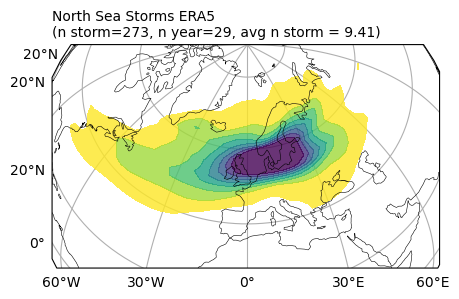

In [16]:
plot_density(trx_hist_djf, 'vor', 'North Sea Storms ERA5')

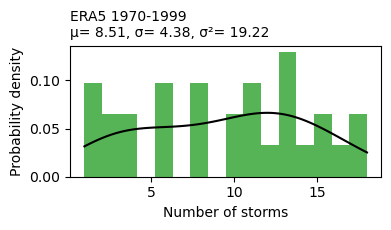

In [23]:
freq_hist_djf = trx_hist_djf.drop_duplicates(subset=['uniq_id'])
year_north_hist = freq_hist_djf['season'].value_counts().sort_index()
year_north_hist = year_north_hist.values.tolist()

fig, axs = plt.subplots(1, 1, figsize=(4.1, 2.4))
kde_trx = gaussian_kde(year_north_hist)
x_trx = np.linspace(min(year_north_hist), max(year_north_hist), 100)
kde_values_trx = kde_trx(x_trx)
mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
std_trx = np.sqrt(var_trx)

axs.hist(year_north_hist, bins=16, density=True, alpha=0.8, color='tab:green')
axs.plot(x_trx, kde_values_trx, label='KDE', color='black')
axs.set_title(f'ERA5 1970-1999 \nμ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Number of storms')
axs.set_ylabel('Probability density')

plt.tight_layout()
plt.show()

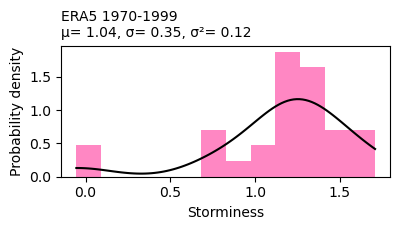

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(4.1, 2.4))

vor_per = trx_hist_djf.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.9))
vor_mean = trx_hist_djf['var_mslp'].mean()
vor_std = trx_hist_djf['var_mslp'].std()
ssi = (vor_per.values - vor_mean) / vor_std

kde_trx = gaussian_kde(ssi)
x_trx = np.linspace(min(ssi), max(ssi), 100)
kde_values_trx = kde_trx(x_trx)
mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
std_trx = np.sqrt(var_trx)

axs.hist(ssi, bins=12, density=True, alpha=0.8, color='hotpink')
axs.plot(x_trx, kde_values_trx, label='KDE', color='black')
axs.set_title(f'ERA5 1970-1999 \nμ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
axs.set_xlabel('Storminess')
axs.set_ylabel('Probability density')

plt.tight_layout()
plt.show()

In [145]:
colori = ['lightsalmon', 'orangered', 'firebrick']

## HadGEM2 Historical Track

In [3]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_var_', 'lat_var_', 'var_var_', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_prec', 'lat_prec', 'var_prec']

fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks-cmip5/'
hadgem_hist = ["tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r1i1p1_pos.addvor_addmslp_addwind",
               "tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r2i1p1_pos.addvor_addmslp_addwind",
               "tr_trs_CMIP5_MOHC_HadGEM2-ES_historical_r1i1p1_pos.addvor_addmslp_addwind"]

trx_CC_r1i1p1 = read_tracks(fpath + hadgem_hist[0], var_names)
trx_CC_r2i1p1 = read_tracks(fpath + hadgem_hist[1], var_names)
trx_ES_r1i1p1 = read_tracks(fpath + hadgem_hist[2], var_names)

In [4]:
trx_CC_r1i1p1.to_csv(f'tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r1i1p1_pos.addvor_addmslp_addwind.csv')
trx_CC_r2i1p1.to_csv(f'tr_trs_CMIP5_MOHC_HadGEM2-CC_historical_r2i1p1_pos.addvor_addmslp_addwind.csv')
trx_ES_r1i1p1.to_csv(f'tr_trs_CMIP5_MOHC_HadGEM2-ES_historical_r1i1p1_pos.addvor_addmslp_addwind.csv')

In [233]:
trx_list = [trx_CC_r1i1p1, trx_CC_r2i1p1, trx_ES_r1i1p1]

for i, trx in enumerate(trx_list):
    trx['is_new_year'] = (trx['ID'] == 1) & (trx['ID'].shift(1) > 1)
    trx.loc[0, 'is_new_year'] = True
    trx['year'] = trx['is_new_year'].cumsum()
    trx.drop(columns=['is_new_year'], inplace=True)
    trx['uniq_id'] = list(zip(trx['year'], trx['ID']))
    trx = trx.sort_values(by=['year', 'ID'])

    trx = calc_speed_dir(trx, 6)
    trx['bearing'] = trx['bearing'].apply(adjust_bearing)
    trx['speed'] = pd.to_numeric(trx['speed'], errors='coerce')
    trx['speed'] = trx['speed'].fillna(trx['speed'].mean())
    
    duration_df = trx.groupby('uniq_id')['date'].agg(['min', 'max'])
    duration_df['duration'] = duration_df['max'] - duration_df['min']
    trx = trx.merge(duration_df['duration'], on='uniq_id')
    trx['duration'] = trx['duration'] * 6

    trx_list[i] = trx
    print(f'DataFrame {i+1}:')
    print(f'Unique years: {trx_list[i]["year"].nunique()}')
    print(f'Unique ID storms: {trx_list[i]["ID"].nunique()}')
    print(f'Unique storm events: {trx_list[i]["uniq_id"].nunique()}\n')

DataFrame 1:
Unique years: 29
Unique ID storms: 495
Unique storm events: 13471

DataFrame 2:
Unique years: 29
Unique ID storms: 493
Unique storm events: 13372

DataFrame 3:
Unique years: 29
Unique ID storms: 491
Unique storm events: 13312



In [236]:
lon_min, lon_max = -6, 9
lat_min, lat_max = 50, 60

trx_north_list = []
names = ['CC_hist_r1i1p1', 'CC_hist_r2i1p1','ES_hist_r1i1p1']

for i, (trx, name) in enumerate(zip(trx_list, names)):
    trx['lon_vor'] = ((trx['lon_vor'] + 180) % 360) - 180
    northsea_bound = trx[
        (trx['lon_vor'] >= lon_min) & 
        (trx['lon_vor'] <= lon_max) &
        (trx['lat_vor'] >= lat_min) & 
        (trx['lat_vor'] <= lat_max)]
    
    #northsea_bound = northsea_bound.sort_values(by=['uniq_id', 'date'])
    valid_storms_wind = northsea_bound.groupby('uniq_id').filter(lambda x: x['var_wind'].min() >= 25)
    #valid_storms = valid_storms_wind.groupby('uniq_id').filter(lambda x: x['distance'].max() <= 350)
    
    
    valid_ids = valid_storms_wind['uniq_id'].unique()
    trx_north = trx[trx['uniq_id'].isin(valid_ids)]
    trx_north = trx_north[trx_north['duration'] >= 48]

    storm_filter = trx_north[(trx_north['lat_vor'] >= 50) & (trx_north['lat_vor'] <= 60) &
                 (trx_north['lon_vor'] >= -10) & (trx_north['lon_vor'] <= 10)]

    category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
    category.columns = ['uniq_id', 'category']
    trx_north = trx_north.merge(category, on='uniq_id', how='left')
    

    north_trx_name = f'north_{name}'
    trx_north_list.append((north_trx_name, trx_north))

/tmp/ipykernel_575/2319254365.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/2319254365.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/2319254365.py:27: DeprecationWarning: DataFrameGroupBy.apply oper

In [237]:
north_trx_CC_hist_r1i1p1 = trx_north_list[0][1]
north_trx_CC_hist_r2i1p1 = trx_north_list[1][1]
north_trx_ES_hist_r1i1p1 = trx_north_list[2][1]
north_trx_list = [north_trx_CC_hist_r1i1p1, north_trx_CC_hist_r2i1p1, north_trx_ES_hist_r1i1p1]

for trx, north_trx in zip(trx_list, north_trx_list):
    print(f'All track uniq_id count: {trx["uniq_id"].nunique()}')
    print(f'North Sea uniq_id count: {north_trx["uniq_id"].nunique()}')
    print(f'All track length: {len(trx)}')
    print(f'North Sea length: {len(north_trx)}\n')

All track uniq_id count: 13471
North Sea uniq_id count: 189
All track length: 260753
North Sea length: 3957

All track uniq_id count: 13372
North Sea uniq_id count: 154
All track length: 261184
North Sea length: 3369

All track uniq_id count: 13312
North Sea uniq_id count: 224
All track length: 259287
North Sea length: 4886



In [9]:
north_trx_CC_hist_r1i1p1= north_trx_CC_hist_r1i1p1[north_trx_CC_hist_r1i1p1['uniq_id'] != (26, 304)]
#north_trx_CC_hist_r1i1p1= north_trx_CC_hist_r1i1p1[north_trx_CC_hist_r1i1p1['lat_vor'] != 12.415297]
north_trx_list = [north_trx_CC_hist_r1i1p1, north_trx_CC_hist_r2i1p1, north_trx_ES_hist_r1i1p1]
#north_trx_CC_hist_r1i1p1[north_trx_CC_hist_r1i1p1['lat_vor'] == 12.415297]
north_trx_CC_hist_r1i1p1['lat_vor'].min()

19.1735

In [80]:
north_trx_CC_hist_r1i1p1[north_trx_CC_hist_r1i1p1['lat_vor'] == 12.415297]
north_trx_CC_hist_r1i1p1[north_trx_CC_hist_r1i1p1['uniq_id'] == '(26, 304)']

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id,distance,speed,bearing


In [8]:
north_trx_title = ['HadGEM2-CC_hist_r1i1p1', 
                   'HadGEM2-CC_hist_r2i1p1',
                   'HadGEM2-ES_hist_r1i1p1']

/tmp/ipykernel_551/206484741.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


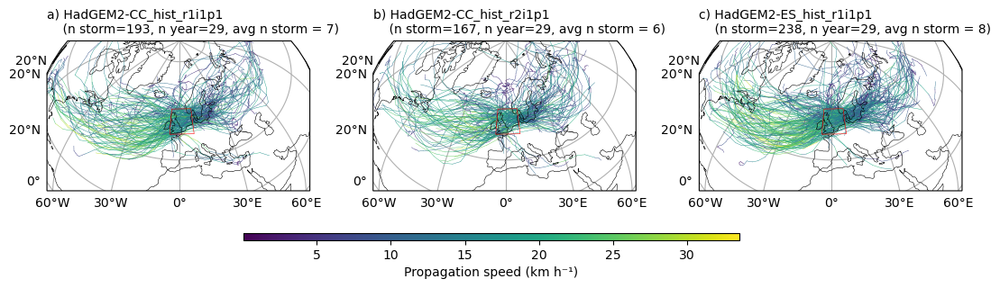

In [118]:
plot_multiple_tracks(north_trx_list, 'speed', north_trx_title)

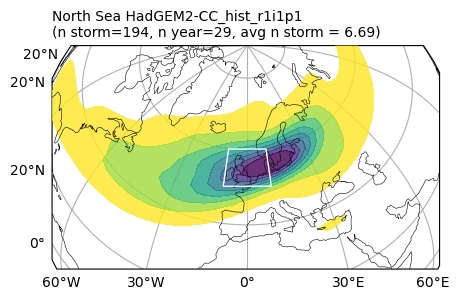

In [48]:
plot_density(north_trx_list[0], 'vor', f'North Sea {north_trx_title[0]}')

/tmp/ipykernel_626/219411662.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


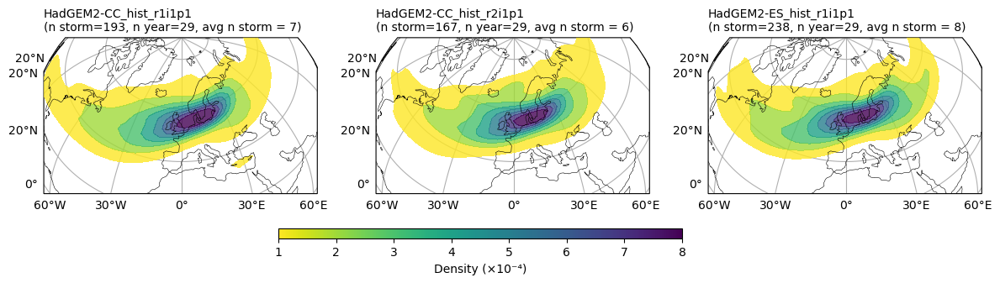

In [206]:
north_trx_title = ['HadGEM2-CC_hist_r1i1p1', 
                   'HadGEM2-CC_hist_r2i1p1',
                   'HadGEM2-ES_hist_r1i1p1']

plot_multiple_track_density(north_trx_list, 'vor', north_trx_title)

In [353]:
freq_north_trx_CC_r1i1p1 = north_trx_CC_hist_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_CC_r1i1p1 = freq_north_trx_CC_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_CC_r1i1p1 = year_freq_north_trx_CC_r1i1p1.values.tolist()

freq_north_trx_CC_r2i1p1 = north_trx_CC_hist_r2i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_CC_r2i1p1 = freq_north_trx_CC_r2i1p1['year'].value_counts().sort_index()
year_freq_north_trx_CC_r2i1p1 = year_freq_north_trx_CC_r2i1p1.values.tolist()

freq_north_trx_ES_r1i1p1 = north_trx_ES_hist_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_ES_r1i1p1 = freq_north_trx_ES_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_ES_r1i1p1 = year_freq_north_trx_ES_r1i1p1.values.tolist()

year_freq_data = [year_freq_north_trx_CC_r1i1p1 , year_freq_north_trx_CC_r2i1p1, year_freq_north_trx_ES_r1i1p1]

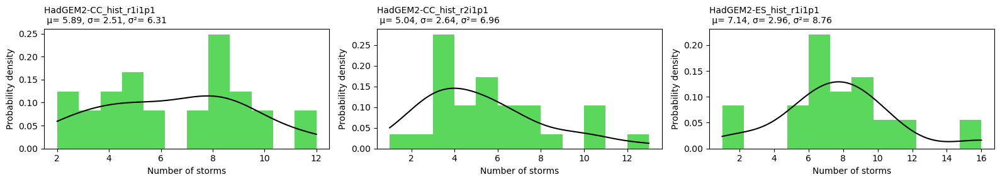

In [27]:
north_trx_title_b = ['HadGEM2-CC_hist_r1i1p1', 
                   'HadGEM2-CC_hist_r2i1p1',
                   'HadGEM2-ES_hist_r1i1p1']

fig, axs = plt.subplots(1, 3, figsize=(16., 3.))
for i, data in enumerate(year_freq_data):
    kde_trx = gaussian_kde(data)
    x_trx = np.linspace(min(data), max(data), 200)
    kde_values_trx = kde_trx(x_trx)
    mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
    var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
    std_trx = np.sqrt(var_trx)

    # Plot the histogram of the data
    axs[i].hist(data, bins=12, density=True, alpha=0.8, color='limegreen')
    axs[i].plot(x_trx, kde_values_trx, label='KDE', color='black')
    axs[i].set_title(f'{north_trx_title_b[i]} \n μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
    axs[i].set_xlabel('Number of storms')
    axs[i].set_ylabel('Probability density')

plt.tight_layout()
plt.show()


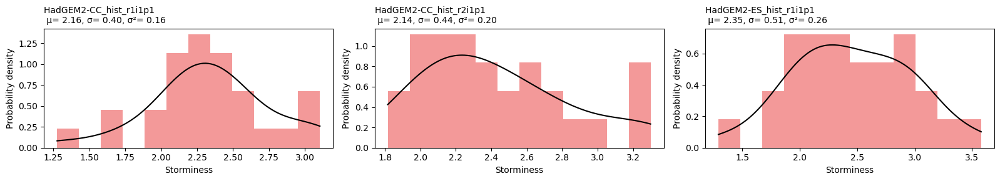

In [89]:
fig, axs = plt.subplots(1, 3, figsize=(16., 3.))
for i, data in enumerate(north_trx_list):
    vor_per = data.groupby('year')['var_vor'].apply(lambda x: x.quantile(0.99))
    vor_mean = data.groupby('year')['var_vor'].mean()
    vor_std = data.groupby('year')['var_vor'].std()
    ssi = (vor_per.values - vor_mean.values) / vor_std.values

    kde_trx = gaussian_kde(ssi)
    x_trx = np.linspace(min(ssi), max(ssi), 100)
    kde_values_trx = kde_trx(x_trx)
    mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
    var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
    std_trx = np.sqrt(var_trx)

    axs[i].hist(ssi, bins=12, density=True, alpha=0.8, color='lightcoral')
    axs[i].plot(x_trx, kde_values_trx, label='KDE', color='black')
    axs[i].set_title(f'{north_trx_title_b[i]} \n μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
    axs[i].set_xlabel('Storminess')
    axs[i].set_ylabel('Probability density')

plt.tight_layout()
plt.show()

## Historical Bias

In [224]:
def plot_track_cat(data_trx, list_data_trx):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    map_extent = [-90, 80, 25, 90]
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180
    
    fig, axs = plt.subplots(2, 2, figsize=(6., 4.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    
    axs[0].add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.5)
    axs[0].set_extent(map_extent, crs=ccrs.PlateCarree())
    for name, group in data_trx.groupby('uniq_id'):
        points = group[['lon_vor', 'lat_vor']].values
        for i in range(len(points) - 1):
                line = np.array([points[i], points[i + 1]])
                axs[0].plot(line[:, 0], line[:, 1], color='tab:green', linewidth=0.25, alpha=0.8, transform=datacrs)
                axs[0].set_title('ERA5', fontsize=10, loc='left')
    
    for idx, data in enumerate(list_data_trx):
        ax = axs[idx+1]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.5)
        ax.set_extent(map_extent, crs=ccrs.PlateCarree())   
        for name, group in data.groupby('uniq_id'):
            points = group[['lon_vor', 'lat_vor']].values
            storm_color = colori[idx]
            for i in range(len(points) - 1):
                line = np.array([points[i], points[i + 1]])
                ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.25, alpha=1, transform=datacrs)
                ax.set_title('HadGEM ' + title_ini[idx], fontsize=10, loc='left')

    plt.tight_layout()
    plt.show()

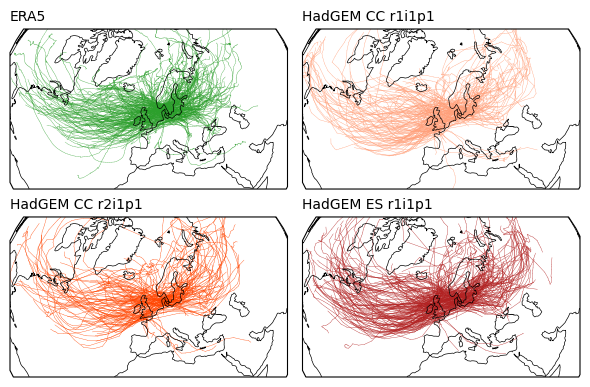

In [225]:
title_ini = ['ERA5', 'HadGEM-CC r1i1p1', 'HadGEM-CC r2i1p1', 'HadGEM-ES r1i1p1']
plot_track_cat(trx_hist_djf, north_trx_list)

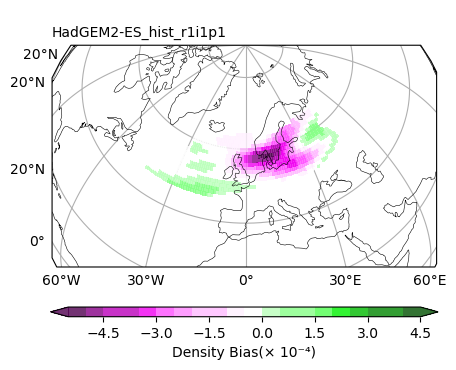

In [77]:
plot_density_bias(north_trx_list[2], trx_hist_djf, 'vor', f'{north_trx_title[2]}')

/tmp/ipykernel_924/2807215159.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


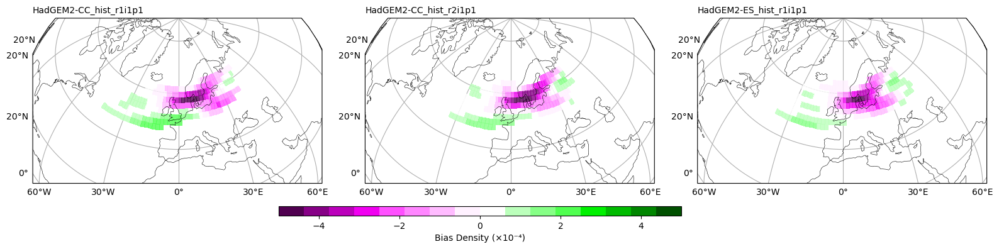

In [16]:
north_trx_title = ['HadGEM2-CC_hist_r1i1p1', 
                   'HadGEM2-CC_hist_r2i1p1',
                   'HadGEM2-ES_hist_r1i1p1']

plot_multiple_bias(north_trx_list, trx_hist_djf, 'vor', north_trx_title)

8.485197644243344
5.88675318047965
5.039938845746084
7.140337499451954


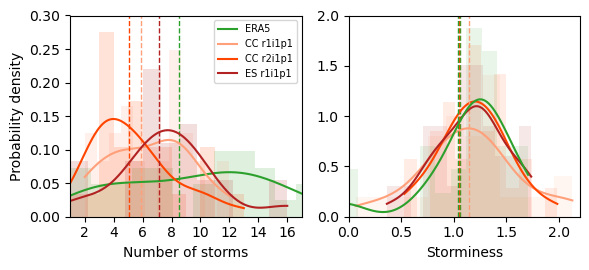

In [52]:
data_freq = [year_north_hist, year_freq_north_trx_CC_r1i1p1 , year_freq_north_trx_CC_r2i1p1, year_freq_north_trx_ES_r1i1p1]
colori = ['lightsalmon', 'orangered', 'firebrick']
# Create the figure with two panels
fig, axs = plt.subplots(1, 2, figsize=(6., 2.8))

# Overlayed Plot 1
for i, data in enumerate(data_freq):
    kde_trx = gaussian_kde(data)
    x_trx = np.linspace(min(data), max(data), 200)
    kde_values_trx = kde_trx(x_trx)
    mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
    var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
    std_trx = np.sqrt(var_trx)

    axs[0].hist(data, bins=12, density=True, alpha=0.15, color=colorset[i])
    axs[0].plot(x_trx, kde_values_trx, label=f'{dataset_labels[i]}', color=colorset[i], linewidth=1.5)
    axs[0].vlines(mean_trx, 0, 0.3, color=colorset[i], linewidth=1, linestyle='--')
    print(mean_trx)
axs[0].set_ylim(0,0.3)
axs[0].set_xticks(np.arange(0,17,2))
axs[0].set_xlim(1,17)
axs[0].set_xlabel('Number of storms')
axs[0].set_ylabel('Probability density')
axs[0].legend(loc='best', fontsize=7)

# Overlayed Plot 2
for i, data in enumerate(north_trx_list):
    vor_per = data.groupby('year')['var_mslp'].apply(lambda x: x.quantile(0.9))
    vor_mean = data['var_mslp'].mean()
    vor_std = data['var_mslp'].std()
    ssi = (vor_per.values - vor_mean) / vor_std

    kde_trx = gaussian_kde(ssi)
    x_trx = np.linspace(min(ssi), max(ssi), 100)
    kde_values_trx = kde_trx(x_trx)
    mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
    var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
    std_trx = np.sqrt(var_trx)

    axs[1].hist(ssi, bins=12, density=True, alpha=0.1, color=colori[i])
    axs[1].plot(x_trx, kde_values_trx, label=f'{north_trx_title_b[i]}', color=colori[i], linewidth=1.5)
    axs[1].vlines(mean_trx, 0, 2, color=colorset[i], linewidth=1, linestyle='--')

vor_perera = trx_hist_djf.groupby('season')['var_mslp'].apply(lambda x: x.quantile(0.9))
vor_meanera = trx_hist_djf['var_mslp'].mean()
vor_stdera = trx_hist_djf['var_mslp'].std()
ssiera = (vor_perera.values - vor_meanera) / vor_stdera

kde_trxe = gaussian_kde(ssiera)
x_trxe = np.linspace(min(ssiera), max(ssiera), 100)
kde_values_trxe = kde_trxe(x_trxe)
mean_trxe = np.sum(x_trxe * kde_values_trxe) * (x_trxe[1] - x_trxe[0])
var_trxe = np.sum((x_trxe - mean_trxe)**2 * kde_values_trxe) * (x_trxe[1] - x_trxe[0])
std_trxe = np.sqrt(var_trxe)
axs[1].hist(ssiera, bins=12, density=True, alpha=0.1, color='tab:green')
axs[1].plot(x_trxe, kde_values_trxe, label='ERA5', color='tab:green', linewidth=1.5)
axs[1].vlines(mean_trxe, 0, 2, color='tab:green', linewidth=1, linestyle='--')
axs[1].set_ylim(0,2)
axs[1].set_xlim(0,2.2)

axs[1].set_xlabel('Storminess')
#axs[1].set_ylabel('Probability density')
#axs[1].legend(loc='best', fontsize=7)

plt.tight_layout()
plt.show()


In [ ]:
variables = ['speed', 'var_vor', 'var_mslp', 'var_wind', 'duration'] 
titles = ['a) Propagation speed\n', 'b) Vorticity\n', 'c) MSLP\n', 'd) 925-hPa max\nwind speed', 'f) Duration\n']
ylabels = ['km hour⁻¹', '× 10⁻⁵ s⁻¹', 'hPa', 'ms⁻¹', 'hour']

datasets = [trx_hist_djf, north_trx_CC_hist_r1i1p1, north_trx_CC_hist_r2i1p1, north_trx_ES_hist_r1i1p1]
dataset_labels = ['ERA5', 'CC r1i1p1', 'CC r2i1p1', 'ES r1i1p1']
colorset = ['tab:green', 'lightsalmon', 'orangered', 'firebrick']

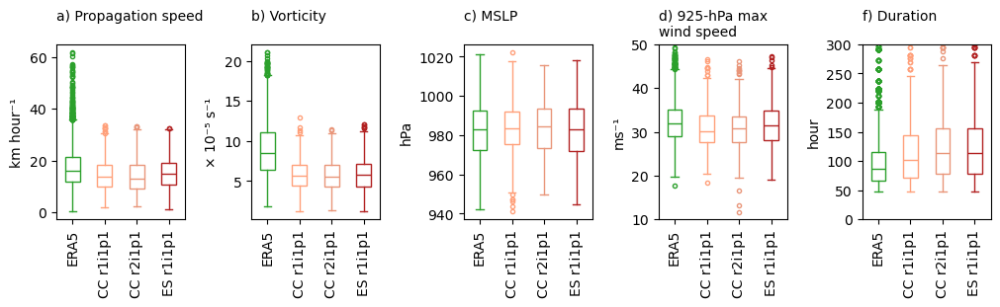

In [37]:
fig, axs = plt.subplots(1, 5, figsize=(10., 3.), constrained_layout=True, gridspec_kw={'wspace':0.1, 'hspace': 0.15})

axs = axs.flatten()
# Loop over each variable to plot
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    data_to_plot = []
    for datax in datasets:
        storm_filter = datax[(datax['lat_vor'] >= 50) & (datax['lat_vor'] <= 60) &
                             (datax['lon_vor'] >= -10) & (datax['lon_vor'] <= 10)]
        if var in storm_filter.columns:
            data_to_plot.append(storm_filter[var].dropna())
    
    # Create the boxplot with consistent colors for each dataset
    box = axs[idx].boxplot(data_to_plot, patch_artist=True, labels=dataset_labels)
    
    # Apply colors to each boxplot element (boxes, whiskers, caps, fliers, medians)
    for i, (patch, color) in enumerate(zip(box['boxes'], colorset)):
        patch.set_facecolor('white')  # White face for boxes
        patch.set_edgecolor(color)    # Colored edge for boxes
        box['medians'][i].set_color(color)
        for j in range(2):  # Two whiskers and two caps per dataset
            box['whiskers'][2 * i + j].set_color(color)
            box['caps'][2 * i + j].set_color(color)
        box['fliers'][i].set(markeredgecolor=color, markersize=3)
    
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].set_xticklabels(dataset_labels, rotation=90, ha='center')
    axs[3].set_ylim(10,50)
    axs[4].set_ylim(0,300)

# Remove any extra axes that don't have corresponding data
for ax in axs[len(variables):]:
    fig.delaxes(ax)

plt.show()


/tmp/ipykernel_575/4192943006.py:80: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


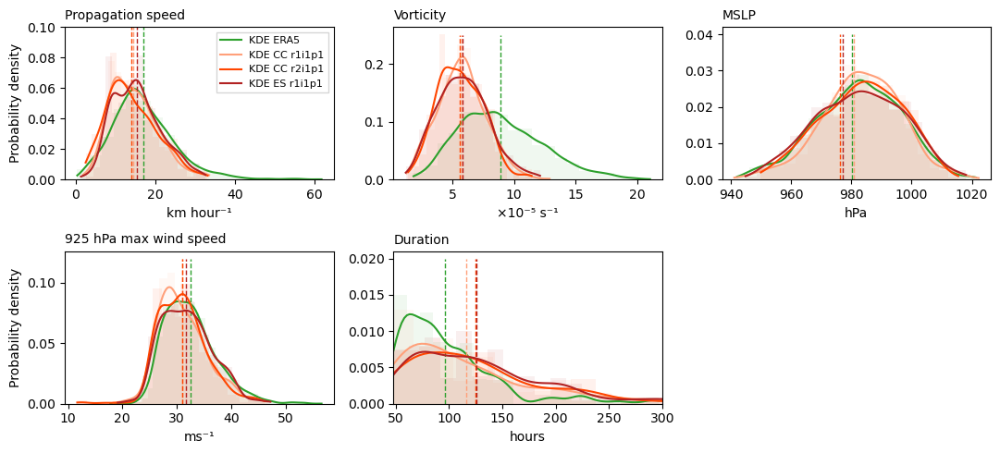

In [331]:
fig, axs = plt.subplots(2, 3, figsize=(11., 5.), constrained_layout=True)
axs = axs.flatten()

for i, datax in enumerate (datasets):
        northsea_bound = datax[(datax['lon_vor'] >= -10) & (datax['lon_vor'] <= 10) & 
                                (datax['lat_vor'] >= 50) & (datax['lat_vor'] <= 60)]

        kde_speed = gaussian_kde(northsea_bound['speed'])
        x_grid_speed = np.linspace(min(northsea_bound['speed']), max(northsea_bound['speed']), 100)
        kde_val_speed = kde_speed(x_grid_speed)
        mean_speed = np.sum(x_grid_speed * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
        var_speed = np.sum((x_grid_speed - mean_speed)**2 * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
        std_speed = np.sqrt(var_speed)

        kde_vor = gaussian_kde(northsea_bound['var_vor'])
        x_grid_vor = np.linspace(min(northsea_bound['var_vor']), max(northsea_bound['var_vor']), 100)
        kde_val_vor = kde_vor(x_grid_vor)
        mean_vor = np.sum(x_grid_vor * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
        var_vor = np.sum((x_grid_vor - mean_vor)**2 * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
        std_vor = np.sqrt(var_vor)

        kde_mslp = gaussian_kde(northsea_bound['var_mslp'])
        x_grid_mslp = np.linspace(min(northsea_bound['var_mslp']), max(northsea_bound['var_mslp']), 100)
        kde_val_mslp = kde_mslp(x_grid_mslp)
        mean_mslp = np.sum(x_grid_mslp * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
        var_mslp = np.sum((x_grid_mslp - mean_mslp)**2 * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
        std_mslp = np.sqrt(var_mslp)

        kde_wind = gaussian_kde(northsea_bound['var_wind'])
        x_grid_wind = np.linspace(min(northsea_bound['var_wind']), max(northsea_bound['var_wind']), 100)
        kde_val_wind = kde_wind(x_grid_wind)
        mean_wind = np.sum(x_grid_wind * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
        var_wind = np.sum((x_grid_wind - mean_wind)**2 * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
        std_wind = np.sqrt(var_wind)

        kde_dur = gaussian_kde(northsea_bound['duration'])
        x_grid_dur = np.linspace(min(northsea_bound['duration']), max(northsea_bound['duration']), 100)
        kde_val_dur = kde_dur(x_grid_dur)
        mean_dur = np.sum(x_grid_dur * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
        var_dur = np.sum((x_grid_dur - mean_dur)**2 * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
        std_dur = np.sqrt(var_dur)

        axs[0].hist(northsea_bound['speed'], bins=20, density=True, alpha=0.07, color=colorset[i])#, label=dataset_labels[i])
        axs[0].plot(x_grid_speed, kde_val_speed, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[0].vlines(mean_speed, 0, 0.48, color=colorset[i], linewidth=1, linestyle='--')
        #axs[0].set_title(f'μ= {mean_speed:.2f}, σ= {std_speed:.2f}, σ²= {var_speed:.2f}', fontsize=10, loc='left')
        axs[0].set_title('Propagation speed', loc='left', fontsize=10)
        axs[0].set_ylim(0,0.1)
        axs[0].set_xlabel('km hour⁻¹')
        axs[0].set_ylabel('Probability density')
        axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8, ncols=1)
        axs[1].hist(northsea_bound['var_vor'], bins=20, density=True, alpha=0.07, color=colorset[i])#, label=dataset_labels[i])
        axs[1].plot(x_grid_vor, kde_val_vor, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[1].vlines(mean_vor, 0, 0.25, color=colorset[i], linewidth=1, linestyle='--')
        #axs[1].set_title(f'{μ= {mean_vor:.2f}, σ= {std_vor:.2f}, σ²= {var_vor:.2f}', fontsize=10, loc='left')
        axs[1].set_title('Vorticity', loc='left', fontsize=10)
        axs[1].set_xlabel('×10⁻⁵ s⁻¹')
        axs[2].hist(northsea_bound['var_mslp'], bins=20, density=True, alpha=0.07, color=colorset[i])#, label=dataset_labels[i])
        axs[2].plot(x_grid_mslp, kde_val_mslp, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[2].vlines(mean_mslp, 0, 0.04, color=colorset[i], linewidth=1, linestyle='--')
        axs[2].set_title('MSLP', loc='left', fontsize=10)
        axs[2].set_xlabel('hPa')
        axs[3].set_ylabel('Probability density')
        axs[3].hist(northsea_bound['var_wind'], bins=20, density=True, alpha=0.07, color=colorset[i])#, label=dataset_labels[i])
        axs[3].plot(x_grid_wind, kde_val_wind, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[3].vlines(mean_wind, 0, 0.12, color=colorset[i], linewidth=1, linestyle='--')
        axs[3].set_title('925 hPa max wind speed', loc='left', fontsize=10)
        axs[3].set_xlabel('ms⁻¹')
        axs[4].hist(northsea_bound['duration'], bins=20, density=True, alpha=0.07, color=colorset[i])#, label=dataset_labels[i])
        axs[4].plot(x_grid_dur, kde_val_dur, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[4].vlines(mean_dur, 0, 0.02, color=colorset[i], linewidth=1, linestyle='--')
        axs[4].set_title('Duration', loc='left', fontsize=10)
        axs[4].set_xlim(48,300)
        axs[4].set_xlabel('hours')
        #axs[4].legend(fontsize=8, fancybox=False, loc='upper left', ncols=2, bbox_to_anchor=(1.01, 1))
        
for ax in axs[5:]:
    fig.delaxes(ax) 
   
plt.tight_layout()
plt.show()

### Storm Direction

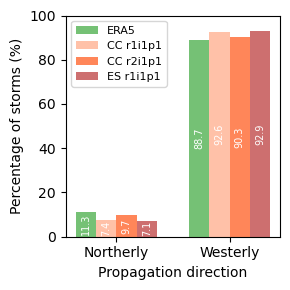

In [129]:
datasets = [trx_hist_djf, north_trx_CC_hist_r1i1p1, north_trx_CC_hist_r2i1p1, north_trx_ES_hist_r1i1p1]
dataset_labels = ['ERA5', 'CC r1i1p1', 'CC r2i1p1', 'ES r1i1p1']
colorset = ['tab:green', 'lightsalmon', 'orangered', 'firebrick']

percentages = []
for data in datasets:
    crop_storm = data.drop_duplicates(subset=['uniq_id'])
    dir_count = crop_storm['category'].value_counts().sort_index()
    dir_count = (dir_count / dir_count.sum()) * 100
    percentages.append(dir_count)

directions = ['Northerly', 'Westerly']
x = range(len(directions))
width = 0.18 

fig, ax = plt.subplots(figsize=(3., 3.))

for i, percent in enumerate(percentages):
    ax.bar([p + i * width for p in x], [percent.get('Northerly', 0), percent.get('Westerly', 0)], 
           width=width, color=colorset[i], alpha=0.65, label=dataset_labels[i])
for container in ax.containers: 
    ax.bar_label(container,fmt='%.1f', label_type='center', fontsize=7, color='white', rotation=90)

ax.set_ylim(0,100)
ax.set_xlabel('Propagation direction')
ax.set_ylabel('Percentage of storms (%)')
ax.set_xticks([p + 1.5 * width for p in x])
ax.set_xticklabels(directions)
ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()


In [76]:
def plot_windrose(data_sim, data_era, title):
    trx_era = data_era.dropna(subset=['bearing', 'speed'])
    northsea_bound = trx_era[
        (trx_era['lon_vor'] >= -4) & 
        (trx_era['lon_vor'] <= 10) & 
        (trx_era['lat_vor'] >= 50) & 
        (trx_era['lat_vor'] <= 60)]
    trx_north_era = northsea_bound.dropna(subset=['bearing', 'speed'])

    trx_sim = data_sim.dropna(subset=['bearing', 'speed'])
    northsea_bound = trx_sim[
            (trx_sim['lon_vor'] >= -4) & 
            (trx_sim['lon_vor'] <= 10) & 
            (trx_sim['lat_vor'] >= 50) & 
            (trx_sim['lat_vor'] <= 60)]
    trx_north_sim = northsea_bound.dropna(subset=['bearing', 'speed'])
    
    fig = plt.figure(figsize=(4., 4.))
    ax = WindroseAxes.from_ax(fig=fig)

    ax.contour(trx_north_sim['bearing'].values, trx_north_sim['speed'].values, label='Sim',
               bins=np.arange(0, 45, 10), cmap=cm.Blues, lw=1.4, alpha=1, normed=True, nsector=32)
        
    ax.contour(trx_north_era['bearing'].values, trx_north_era['speed'].values, 
               bins=np.arange(0, 45, 10), cmap=cm.Reds, lw=1.3, alpha=1, label='ERA5', normed=True, nsector=32)
        
    ax.set_yticklabels([5, 10, 15, 20, 25], fontsize=7)
    ax.set_legend(title="Propagation speed\n(km hour⁻¹)", title_fontsize=9, loc="lower left", fontsize=8)
    ax.set_title(title, loc='left', fontsize=10)

    plt.show()

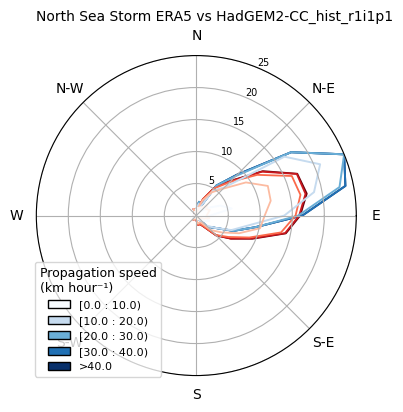

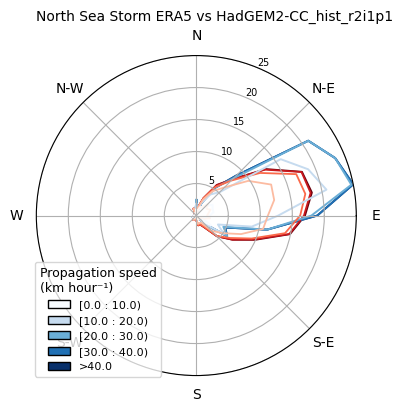

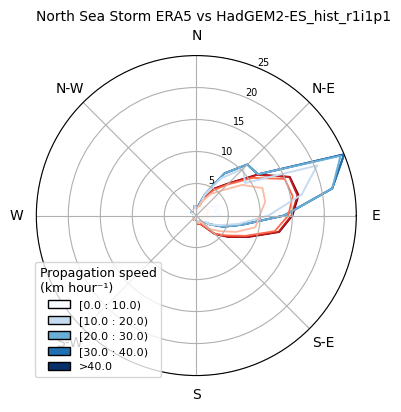

In [77]:
north_trx_title_b = ['HadGEM2-CC_hist_r1i1p1', 
                   'HadGEM2-CC_hist_r2i1p1',
                   'HadGEM2-ES_hist_r1i1p1']

for z, (data, i) in enumerate(zip(north_trx_list, north_trx_title_b)):
    plot_windrose(data, trx_hist_djf, f'North Sea Storm ERA5 vs {i}')

#### Experiment Storm Cats

In [ ]:
from sklearn.cluster import KMeans

def resample_tracks(df, num_points=100):
    resampled_tracks = []
    grouped_tracks = df.groupby('uniq_id')
    
    for name, group in grouped_tracks:
        group = group.sort_values(by='date')
        resampled_track = group[['lat_vor', 'lon_vor']].apply(
            lambda x: np.interp(np.linspace(0, len(x)-1, num_points), np.arange(len(x)), x))
        resampled_tracks.append(resampled_track.values.flatten())
    
    return np.array(resampled_tracks), list(grouped_tracks.groups.keys())

def perform_kmeans(resampled_tracks, track_ids, n_clusters=20):
    kmeans = KMeans(n_clusters=n_clusters)
    kmeans.fit(resampled_tracks)
    labels = kmeans.labels_

    representative_tracks = []
    
    for cluster in range(n_clusters):
        cluster_indices = np.where(labels == cluster)[0]
        cluster_tracks = resampled_tracks[cluster_indices]

        cluster_centroid = kmeans.cluster_centers_[cluster]
        distances = np.linalg.norm(cluster_tracks - cluster_centroid, axis=1)
        representative_track_index = cluster_indices[np.argmin(distances)]
        representative_track_id = track_ids[representative_track_index]
        representative_tracks.append(representative_track_id)
    
    return representative_tracks

In [ ]:
# Apply the function to each dataset
datasets = {
    'hist': trx_hist_djf,
    'ccr1': north_trx_CC_hist_r1i1p1,
    'ccr2': north_trx_CC_hist_r2i1p1,
    'esr1': north_trx_ES_hist_r1i1p1
}

num_points = 200
n_clusters = 7
representative_tracks_dict = {}

for key, df in datasets.items():
    resampled_tracks, track_ids = resample_tracks(df, num_points)
    representative_track_ids = perform_kmeans(resampled_tracks, track_ids, n_clusters)
    
    # Store the representative tracks for each dataset
    representative_tracks_dict[key] = [df[df['uniq_id'] == track_id] for track_id in representative_track_ids]

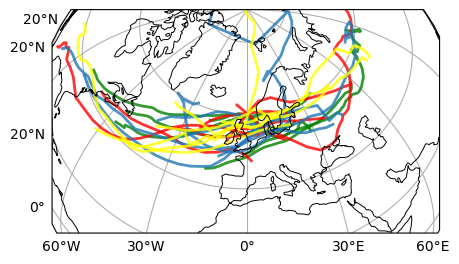

In [198]:
def plot_track_cat(data_trx_reduce, colorset):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    map_extent = [-90, 80, 25, 90]

    fig, ax = plt.subplots(figsize=(5., 4.), subplot_kw={'projection': mapcrs})
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    for i, (key, data_list) in enumerate(data_trx_reduce.items()):
        for track in data_list:
            points = track[['lon_vor', 'lat_vor']].values
            ax.plot(points[:, 0], points[:, 1], color=colorset[i % len(colorset)], linewidth=2, alpha=0.8, transform=datacrs)

    plt.show()
colorsete = ['green', 'red', 'tab:blue', 'yellow']
plot_track_cat(representative_tracks_dict, colorsete)

In [196]:
def storm_prop_dir(df):
    df['prop_dir'] = 'Uncategorized'
    
    for uniq_id in df['uniq_id'].unique():
        storm_track = df[df['uniq_id'] == uniq_id].sort_values(by='date')
        
        for i in range(1, len(storm_track)):
            if storm_track.iloc[i-1]['lon_vor'] < -4 and storm_track.iloc[i]['lon_vor'] >= -4:
                lat_before = storm_track.iloc[i-1]['lat_vor']
                lat_after = storm_track.iloc[i]['lat_vor']
                
                if lat_before >= 60:
                    df.loc[df['uniq_id'] == uniq_id, 'prop_dir'] = 'Northerly'
                elif lat_before >= 50:
                    df.loc[df['uniq_id'] == uniq_id, 'prop_dir'] = 'Zonal'
                else:
                    df.loc[df['uniq_id'] == uniq_id, 'prop_dir'] = 'Tilted'
                
                break
    
    return df

In [197]:
for i, data in enumerate(north_trx_list):
    north_trx_list[i] = storm_prop_dir(data)

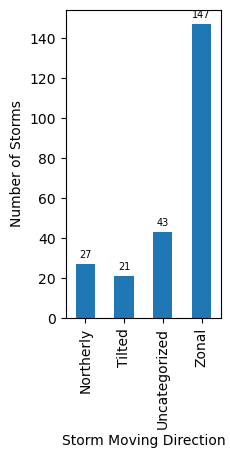

In [198]:
crop_storm = north_trx_list[2].drop_duplicates(subset=['uniq_id'])
dir_count = crop_storm['prop_dir'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(2, 3))
bars = dir_count.plot(kind='bar', color='tab:blue', ax=ax)

for bar in bars.patches:
    height = bar.get_height()
    ax.annotate(f'{height}', xy=(bar.get_x() + bar.get_width() / 2, height), 
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', size=7)

plt.xlabel('Storm Moving Direction')
plt.ylabel('Number of Storms')
plt.show()

In [200]:
def plot_track_cat(data_trx):
    # Define the coordinate reference systems
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

    # Normalize longitude to be between -180 and 180
    data_trx['lon_vor'] = ((data_trx['lon_vor'] + 180) % 360) - 180

    # Count the number of unique storms
    n_storm = data_trx['uniq_id'].nunique()

   # Define color mapping for each category
    #color_mapping = {
    #    'Northerly': 'tab:blue',
    #    'Westerly': 'orange',
    #    'Unknown': 'tab:gray'}
    color_mapping = {
        'Zonal': 'tab:green',
        'Uncategorized': 'tab:purple',
        'Tilted': 'orange',
        'Northerly': 'tab:blue' }

    # Fill missing categories with 'Unknown'
    #data_trx['category'] = data_trx['category'].fillna('Unknown')

    # Create the plot
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': mapcrs})
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='black')

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Plot each storm track
    for name, group in data_trx.groupby('uniq_id'):
        points = group[['lon_vor', 'lat_vor']].values
        storm_color = color_mapping[group['prop_dir'].iloc[0]] 
        #storm_color = color_mapping[group['cluster'].iloc[0]] 
        # Plot lines between consecutive points
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            ax.plot(line[:, 0], line[:, 1], color=storm_color, linewidth=0.5, alpha=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-2, 50], width=2, height=360, zorder=18, facecolor='none', edgecolor='black', transform=datacrs))
    #ax.legend()
    # ax.set_title(f"North Sea's Storm within Thames Barrier Closure Date Window (n={n_storm})")

    plt.show()


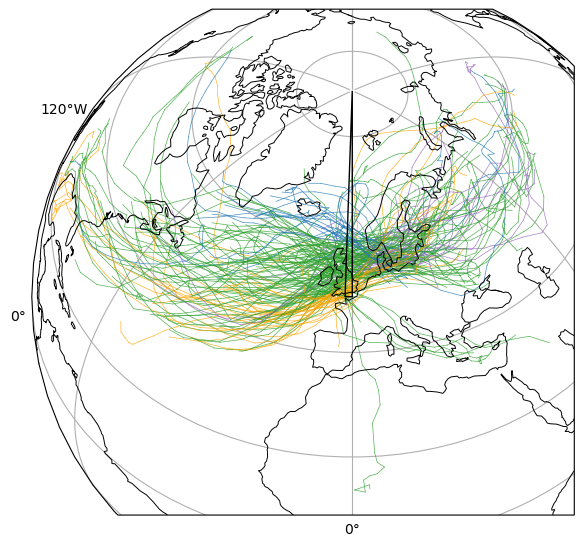

In [201]:
plot_track_cat(north_trx_list[0])

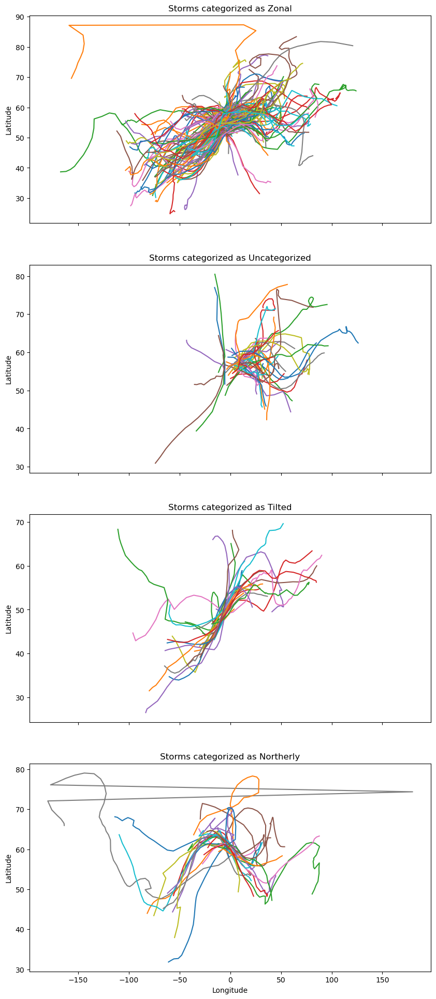

In [194]:
unique_dirs = north_trx_list[0]['prop_dir'].unique()

# Create subplots: one subplot for each unique prop_dir
fig, axes = plt.subplots(len(unique_dirs), 1, figsize=(6, 6 * len(unique_dirs)), sharex=True)

# If there's only one prop_dir, axes might not be an array, so handle that
if len(unique_dirs) == 1:
    axes = [axes]

# Loop over each prop_dir and corresponding subplot
for ax, prop_dir in zip(axes, unique_dirs):
    # Filter storms with the current prop_dir
    for uniq_id in north_trx_list[2][north_trx_list[2]['prop_dir'] == prop_dir]['uniq_id'].unique():
        storm = north_trx_list[2][north_trx_list[2]['uniq_id'] == uniq_id]
        ax.plot(storm['lon_vor'], storm['lat_vor'])
    
    # Set title and labels for the current subplot
    ax.set_title(f'Storms categorized as {prop_dir}')
    ax.set_ylabel('Latitude')

# Set common x-label
axes[-1].set_xlabel('Longitude')

plt.show()

### Bias correction with ERA5

In [ ]:
from scipy.stats import gaussian_kde

# Function to calculate PDF using Gaussian KDE
def calculate_pdf(data, bw_method='scott'):
    kde = gaussian_kde(data, bw_method=bw_method)
    return kde

# Function to perform quantile mapping for bias correction
def quantile_mapping(model_data, observed_data, num_quantiles=1000):
    model_quantiles = np.linspace(0, 1, num_quantiles)
    observed_quantiles = np.quantile(observed_data, model_quantiles)
    model_quantiles_values = np.quantile(model_data, model_quantiles)
    
    # Create a mapping function
    correction_function = np.interp(model_data, model_quantiles_values, observed_quantiles)
    return correction_function

In [ ]:
def calculate_quantile_mapping_function(original_model_data, observed_data, num_quantiles=1000):
    model_quantiles = np.linspace(0, 1, num_quantiles)
    observed_quantiles = np.quantile(observed_data, model_quantiles)
    model_quantiles_values = np.quantile(original_model_data, model_quantiles)
    
    return model_quantiles_values, observed_quantiles

# Example data
observed_data = np.random.normal(loc=0, scale=1, size=1000)  # Replace with actual observed data
original_model_data = np.random.normal(loc=1, scale=1.5, size=1000)  # Replace with actual model data

# Calculate the quantile mapping function
model_quantiles_values, observed_quantiles = calculate_quantile_mapping_function(original_model_data, observed_data)

In [29]:
cornorth_trx_CC_r1i1p1 = quantile_mapping(year_freq_data[0], year_north_hist)
cornorth_trx_CC_r2i1p1 = quantile_mapping(year_freq_data[1], year_north_hist)
cornorth_trx_ES_r1i1p1 = quantile_mapping(year_freq_data[2], year_north_hist)

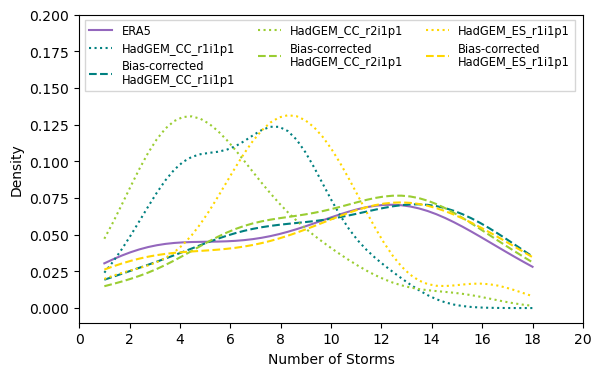

In [115]:
observed_pdf_1 = calculate_pdf(year_north_hist)
model_pdf_1 = calculate_pdf(year_freq_data[0])
corrected_pdf_1 = calculate_pdf(cornorth_trx_CC_r1i1p1)
model_pdf_2 = calculate_pdf(year_freq_data[1])
corrected_pdf_2 = calculate_pdf(cornorth_trx_CC_r2i1p1)
model_pdf_3 = calculate_pdf(year_freq_data[2])
corrected_pdf_3 = calculate_pdf(cornorth_trx_ES_r1i1p1)

# Generate x-values for plotting
x1 = np.linspace(min(min(year_north_hist), min(year_freq_data[0]), cornorth_trx_CC_r1i1p1.min()), 
                max(max(year_north_hist), max(year_freq_data[0]), cornorth_trx_CC_r1i1p1.max()), 50)
x2 = np.linspace(min(min(year_north_hist), min(year_freq_data[1]), cornorth_trx_CC_r2i1p1.min()), 
                max(max(year_north_hist), max(year_freq_data[1]), cornorth_trx_CC_r2i1p1.max()), 50)
x3 = np.linspace(min(min(year_north_hist), min(year_freq_data[2]), cornorth_trx_ES_r1i1p1.min()), 
                max(max(year_north_hist), max(year_freq_data[2]), cornorth_trx_ES_r1i1p1.max()), 50)

# Plot the PDFs
plt.figure(figsize=(6.5, 4.))
plt.plot(x1, observed_pdf_1(x1), label='ERA5', linestyle='-', color='tab:purple')
plt.plot(x1, model_pdf_1(x1), label='HadGEM_CC_r1i1p1', linestyle=':', color='teal')
plt.plot(x1, corrected_pdf_1(x1), label='Bias-corrected\nHadGEM_CC_r1i1p1', linestyle='--', color='teal')
plt.plot(x1, model_pdf_2(x2), label='HadGEM_CC_r2i1p1', linestyle=':', color='yellowgreen')
plt.plot(x1, corrected_pdf_2(x2), label='Bias-corrected\nHadGEM_CC_r2i1p1', linestyle='--', color='yellowgreen')
plt.plot(x1, model_pdf_3(x3), label='HadGEM_ES_r1i1p1', linestyle=':', color='gold')
plt.plot(x1, corrected_pdf_3(x3), label='Bias-corrected\nHadGEM_ES_r1i1p1', linestyle='--', color='gold')
plt.ylim(-0.01,0.2)
plt.xticks(np.arange(0, 21, 2))
plt.xlabel('Number of Storms')
plt.ylabel('Density')
plt.legend(fontsize=8.25, ncol=3, fancybox=False, loc='upper left')
plt.grid(False)
plt.show()


## HadGEM2 Projection Track

In [5]:
var_names = ['date', 'lon_vor', 'lat_vor', 'var_vor', 'lon_var_', 'lat_var_', 'var_var_', 'lon_mslp', 'lat_mslp', 'var_mslp',
            'lon_wind', 'lat_wind', 'var_wind', 'lon_wind2', 'lat_wind2', 'var_wind2']

fpath = '/gws/nopw/j04/canari/users/bjharvey/tracks-cmip5/'
hadgem_proj = ["tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
                "tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r1i1p1_pos.addvor_addmslp_addwind",
                "tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r2i1p1_pos.addvor_addmslp_addwind",
                "tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp45_r1i1p1_pos.addvor_addmslp_addwind",
                "tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1_pos.addvor_addmslp_addwind"]

trx_CC_rcp45_r1i1p1 = read_tracks(fpath + hadgem_proj[0], var_names)
trx_CC_rcp85_r1i1p1 = read_tracks(fpath + hadgem_proj[1], var_names)
trx_CC_rcp85_r2i1p1 = read_tracks(fpath + hadgem_proj[2], var_names)
trx_ES_rcp45_r1i1p1 = read_tracks(fpath + hadgem_proj[3], var_names)
trx_ES_rcp85_r1i1p1 = read_tracks(fpath + hadgem_proj[4], var_names)

In [6]:
trx_CC_rcp45_r1i1p1.to_csv("tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1_pos.addvor_addmslp_addwind.csv")
trx_CC_rcp85_r1i1p1.to_csv("tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r1i1p1_pos.addvor_addmslp_addwind.csv")
trx_CC_rcp85_r2i1p1.to_csv("tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp85_r2i1p1_pos.addvor_addmslp_addwind.csv")
trx_ES_rcp45_r1i1p1.to_csv("tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp45_r1i1p1_pos.addvor_addmslp_addwind.csv")
trx_ES_rcp85_r1i1p1.to_csv("tr_trs_CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1_pos.addvor_addmslp_addwind.csv")

In [15]:
trx_list = [trx_CC_rcp45_r1i1p1,
trx_CC_rcp85_r1i1p1,
trx_CC_rcp85_r2i1p1,
trx_ES_rcp45_r1i1p1,
trx_ES_rcp85_r1i1p1]

for i, trx in enumerate(trx_list):
    trx['is_new_year'] = (trx['ID'] == 1) & (trx['ID'].shift(1) > 1)
    trx.loc[0, 'is_new_year'] = True
    trx['year'] = trx['is_new_year'].cumsum()
    trx.drop(columns=['is_new_year'], inplace=True)
    trx['uniq_id'] = list(zip(trx['year'], trx['ID']))
    trx = trx.sort_values(by=['year', 'ID'])

    trx = calc_speed_dir(trx, 6)
    trx['bearing'] = trx['bearing'].apply(adjust_bearing)
    trx['speed'] = pd.to_numeric(trx['speed'], errors='coerce')
    trx['speed'] = trx['speed'].fillna(trx['speed'].mean())

    duration_df = trx.groupby('uniq_id')['date'].agg(['min', 'max'])
    duration_df['duration'] = duration_df['max'] - duration_df['min']
    trx = trx.merge(duration_df['duration'], on='uniq_id')
    trx['duration'] = trx['duration'] * 6
    
    trx_list[i] = trx
    print(f'DataFrame {i+1}:')
    print(f'Unique years: {trx_list[i]["year"].nunique()}')
    print(f'Unique ID storms: {trx_list[i]["ID"].nunique()}')
    print(f'Unique storm events: {trx_list[i]["uniq_id"].nunique()}\n')


DataFrame 1:
Unique years: 28
Unique ID storms: 498
Unique storm events: 12788

DataFrame 2:
Unique years: 28
Unique ID storms: 479
Unique storm events: 12397

DataFrame 3:
Unique years: 28
Unique ID storms: 479
Unique storm events: 12404

DataFrame 4:
Unique years: 28
Unique ID storms: 485
Unique storm events: 12631

DataFrame 5:
Unique years: 28
Unique ID storms: 471
Unique storm events: 12360



In [16]:
lon_min, lon_max = -6, 9
lat_min, lat_max = 50, 60

trx_north_list = []
names = ['CC_rcp45_r1i1p1', 'CC_rcp85_r1i1p1', 'CC_rcp85_r2i1p1', 'ES_rcp45_r1i1p1', 'ES_rcp85_r1i1p1']

for i, (trx, name) in enumerate(zip(trx_list, names)):
    trx['lon_vor'] = ((trx['lon_vor'] + 180) % 360) - 180
    northsea_bound = trx[
        (trx['lon_vor'] >= lon_min) & 
        (trx['lon_vor'] <= lon_max) &
        (trx['lat_vor'] >= lat_min) & 
        (trx['lat_vor'] <= lat_max)]
    
    #northsea_bound = northsea_bound.sort_values(by=['uniq_id', 'date'])
    valid_storms_wind = northsea_bound.groupby('uniq_id').filter(lambda x: x['var_wind'].min() >= 25)
    #valid_storms = valid_storms_wind.groupby('uniq_id').filter(lambda x: x['distance'].max() <= 350)
    
    valid_ids = valid_storms_wind['uniq_id'].unique()
    trx_north = trx[trx['uniq_id'].isin(valid_ids)]
    trx_north = trx_north[trx_north['duration'] >= 48]
    #trx_north = trx[trx['uniq_id'].isin(valid_ids)]
    storm_filter = trx_north[(trx_north ['lat_vor'] >= 50) & (trx_north ['lat_vor'] <= 60) &
                 (trx_north ['lon_vor'] >= -10) & (trx_north['lon_vor'] <= 10)]
    category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
    category.columns = ['uniq_id', 'category']
    trx_north  = trx_north .merge(category, on='uniq_id', how='left')
    north_trx_name = f'north_{name}'
    trx_north_list.append((north_trx_name, trx_north))

/tmp/ipykernel_575/3515133026.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/3515133026.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/3515133026.py:25: DeprecationWarning: DataFrameGroupBy.apply oper

In [125]:
north_trx_CC_rcp45_r1i1p1

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id,distance,speed,bearing,duration
1140,37.0,-30.457611,47.868523,3.992385,332.8125,48.125,11.258600,325.47550,47.40636,998.3339,329.0625,45.625,31.85993,59,1,"(1, 59)",596.146030,27.599353,62.494691,282.0
1141,38.0,-23.055267,50.113407,4.746869,338.4375,50.625,19.421360,337.95200,50.97000,993.6282,340.3125,49.375,35.52025,59,1,"(1, 59)",554.332056,25.663521,58.706256,282.0
1142,39.0,-16.071594,52.499821,6.055594,344.0625,53.125,22.741530,343.40310,53.43531,988.5953,345.9375,51.875,37.91646,59,1,"(1, 59)",495.052592,22.919102,52.997276,282.0
1143,40.0,-9.884308,55.022774,6.419372,351.5625,55.625,21.060530,349.86690,56.01674,983.7294,353.4375,54.375,38.73567,59,1,"(1, 59)",477.222624,22.093640,46.824071,282.0
1144,41.0,-4.023102,57.822704,6.727731,357.1875,59.375,20.074950,355.27830,58.76651,977.4389,359.0625,56.875,37.14573,59,1,"(1, 59)",378.493495,17.522847,45.741795,282.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250406,227.0,37.947506,60.716381,5.527280,34.6875,60.625,13.048350,35.07088,60.21283,970.6552,47.8125,58.125,28.95715,279,28,"(28, 279)",273.881126,12.679682,26.396167,66.0
250407,228.0,40.341976,62.897701,5.047826,38.4375,63.125,13.036760,38.21331,62.49866,971.9681,49.6875,59.375,25.84302,279,28,"(28, 279)",329.045331,15.233580,23.938482,66.0
250408,229.0,43.233612,65.568275,4.453283,42.1875,65.625,13.192510,41.02210,64.67930,974.1974,53.4375,61.875,19.63872,279,28,"(28, 279)",296.791142,13.740331,29.283351,66.0
250409,230.0,46.683842,67.853653,4.072307,44.0625,66.875,11.679270,43.98121,66.79321,976.3634,51.5625,65.625,17.36079,279,28,"(28, 279)",342.889694,15.874523,41.488191,66.0


In [17]:
north_trx_CC_rcp45_r1i1p1 = trx_north_list[0][1]
north_trx_CC_rcp85_r1i1p1 = trx_north_list[1][1]
north_trx_CC_rcp85_r2i1p1 = trx_north_list[2][1]
north_trx_ES_rcp45_r1i1p1 = trx_north_list[3][1]
north_trx_ES_rcp85_r1i1p1 = trx_north_list[4][1]

north_trx_list_proj = [north_trx_CC_rcp45_r1i1p1,
north_trx_ES_rcp45_r1i1p1,
north_trx_CC_rcp85_r1i1p1,
north_trx_ES_rcp85_r1i1p1,
north_trx_CC_rcp85_r2i1p1]

In [127]:
north_trx_CC_rcp45_r1i1p1

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,...,lat_wind,var_wind,ID,year,uniq_id,distance,speed,bearing,duration,category
0,37.0,-30.457611,47.868523,3.992385,332.8125,48.125,11.258600,325.47550,47.40636,998.3339,...,45.625,31.85993,59,1,"(1, 59)",596.146030,27.599353,62.494691,282.0,Westerly
1,38.0,-23.055267,50.113407,4.746869,338.4375,50.625,19.421360,337.95200,50.97000,993.6282,...,49.375,35.52025,59,1,"(1, 59)",554.332056,25.663521,58.706256,282.0,Westerly
2,39.0,-16.071594,52.499821,6.055594,344.0625,53.125,22.741530,343.40310,53.43531,988.5953,...,51.875,37.91646,59,1,"(1, 59)",495.052592,22.919102,52.997276,282.0,Westerly
3,40.0,-9.884308,55.022774,6.419372,351.5625,55.625,21.060530,349.86690,56.01674,983.7294,...,54.375,38.73567,59,1,"(1, 59)",477.222624,22.093640,46.824071,282.0,Westerly
4,41.0,-4.023102,57.822704,6.727731,357.1875,59.375,20.074950,355.27830,58.76651,977.4389,...,56.875,37.14573,59,1,"(1, 59)",378.493495,17.522847,45.741795,282.0,Westerly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4196,227.0,37.947506,60.716381,5.527280,34.6875,60.625,13.048350,35.07088,60.21283,970.6552,...,58.125,28.95715,279,28,"(28, 279)",273.881126,12.679682,26.396167,66.0,Westerly
4197,228.0,40.341976,62.897701,5.047826,38.4375,63.125,13.036760,38.21331,62.49866,971.9681,...,59.375,25.84302,279,28,"(28, 279)",329.045331,15.233580,23.938482,66.0,Westerly
4198,229.0,43.233612,65.568275,4.453283,42.1875,65.625,13.192510,41.02210,64.67930,974.1974,...,61.875,19.63872,279,28,"(28, 279)",296.791142,13.740331,29.283351,66.0,Westerly
4199,230.0,46.683842,67.853653,4.072307,44.0625,66.875,11.679270,43.98121,66.79321,976.3634,...,65.625,17.36079,279,28,"(28, 279)",342.889694,15.874523,41.488191,66.0,Westerly


In [18]:
for i, data in enumerate(north_trx_list_proj):
    storm_filter = data[(data['lat_vor'] >= 50) & (data['lat_vor'] <= 60) &
                 (data['lon_vor'] >= -10) & (data['lon_vor'] <= 10)]

    category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
    category.columns = ['uniq_id', 'category']

    data = data.merge(category, on='uniq_id', how='left')
    north_trx_list_proj[i] = data

/tmp/ipykernel_575/247726212.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/247726212.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_575/247726212.py:5: DeprecationWarning: DataFrameGroupBy.apply operated o

In [146]:
for trx, north_trx in zip(trx_list, north_trx_list):
    print(f'All track uniq_id count: {trx["uniq_id"].nunique()}')
    print(f'North Sea uniq_id count: {north_trx["uniq_id"].nunique()}')
    print(f'All track length: {len(trx)}')
    print(f'North Sea length: {len(north_trx)}\n')

All track uniq_id count: 12788
North Sea uniq_id count: 181
All track length: 253358
North Sea length: 4201

All track uniq_id count: 12397
North Sea uniq_id count: 203
All track length: 246077
North Sea length: 4188

All track uniq_id count: 12404
North Sea uniq_id count: 164
All track length: 248666
North Sea length: 3762

All track uniq_id count: 12631
North Sea uniq_id count: 206
All track length: 250096
North Sea length: 4547

All track uniq_id count: 12360
North Sea uniq_id count: 138
All track length: 247876
North Sea length: 2989



In [248]:
def plot_track(data, var, fig_title):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  
    
    fig, ax = plt.subplots(figsize=(7., 6.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.6)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    cmap = plt.cm.viridis_r
    norm = mcolors.Normalize(vmin=data[var].min(), vmax=data[var].max())
    n_storm = data['uniq_id'].nunique()
    n_year = data["year"].nunique()
    avg_n_storm = n_storm / n_year 

    for name, group in data.groupby('uniq_id'):
        group[var] = pd.to_numeric(group[var], errors='coerce')
        group[var] = group[var].fillna(group[var].mean())
        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[var].values)
        colors = cmap(color_values)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.7,
                                facecolor='none', edgecolor='red', transform=datacrs))
        
    ax.set_title(fig_title + f" (n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.0f})", fontsize=10, loc='left')
    #labelin = 'Propagation speed (km/h)'
    labelin = 'Vorticity (×10⁻⁵ s⁻¹)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=60, orientation='horizontal', label=labelin)
    plt.show()


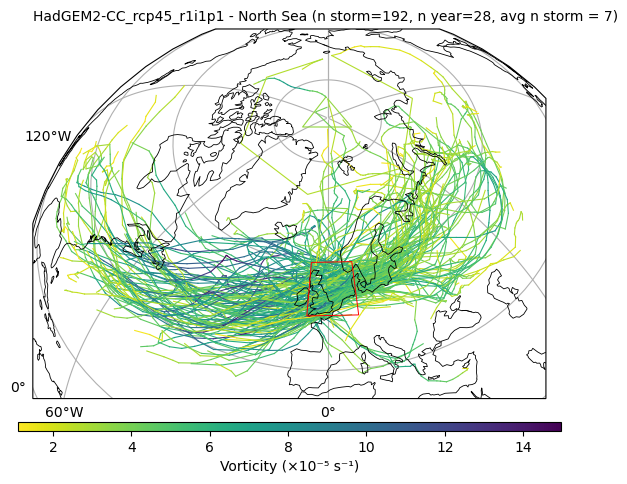

In [249]:
import matplotlib.colors as mcolors
plot_track(north_trx_CC_rcp45_r1i1p1, 'var_vor', 'HadGEM2-CC_rcp45_r1i1p1 - North Sea')

In [15]:
def plot_multiple_tracks(data_list, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)

    fig, axs = plt.subplots(3, 2, figsize=(8., 10.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    global_min = min(data[var].min() for data in data_list)
    global_max = max(data[var].max() for data in data_list)
    norm = mcolors.Normalize(vmin=global_min, vmax=global_max)

    for idx, (data, title) in enumerate(zip(data_list, fig_titles)):
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = plt.cm.viridis
        n_storm = data['uniq_id'].nunique()
        n_year = data["year"].nunique()
        avg_n_storm = n_storm / n_year 

        for name, group in data.groupby('uniq_id'):
            group[var] = pd.to_numeric(group[var], errors='coerce')
            group[var] = group[var].fillna(group[var].mean())
            points = group[['lon_vor', 'lat_vor']].values
            color_values = norm(group[var].values)
            colors = cmap(color_values)

            for i in range(len(points) - 1):
                line = np.array([points[i], points[i + 1]])
                mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
                ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.3, transform=datacrs)

        ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.4,
                                        facecolor='none', edgecolor='red', transform=datacrs))
        ax.set_title(title + f" \n(n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.0f})", fontsize=11, loc='left')

    if len(data_list) < len(axs):
        fig.delaxes(axs[-1])

        # Add a single colorbar for all subplots
    #cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.8])
    cbar_ax = fig.add_axes([0.125, 0.001, 0.8, 0.014])  # Position and size of colorbar
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    #cbar.set_label('Vorticity (×10⁻⁵ s⁻¹)')
    cbar.set_label("Propagation speed (km h⁻¹)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

In [79]:
north_trx_title = ['HadGEM2-CC_rcp45_r1i1p1', 
                   'HadGEM2-ES_rcp45_r1i1p1',
                   'HadGEM2-CC_rcp85_r1i1p1', 
                    'HadGEM2-ES_rcp85_r1i1p1', 
                    'HadGEM2-CC_rcp85_r2i1p1']

/tmp/ipykernel_805/787974637.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


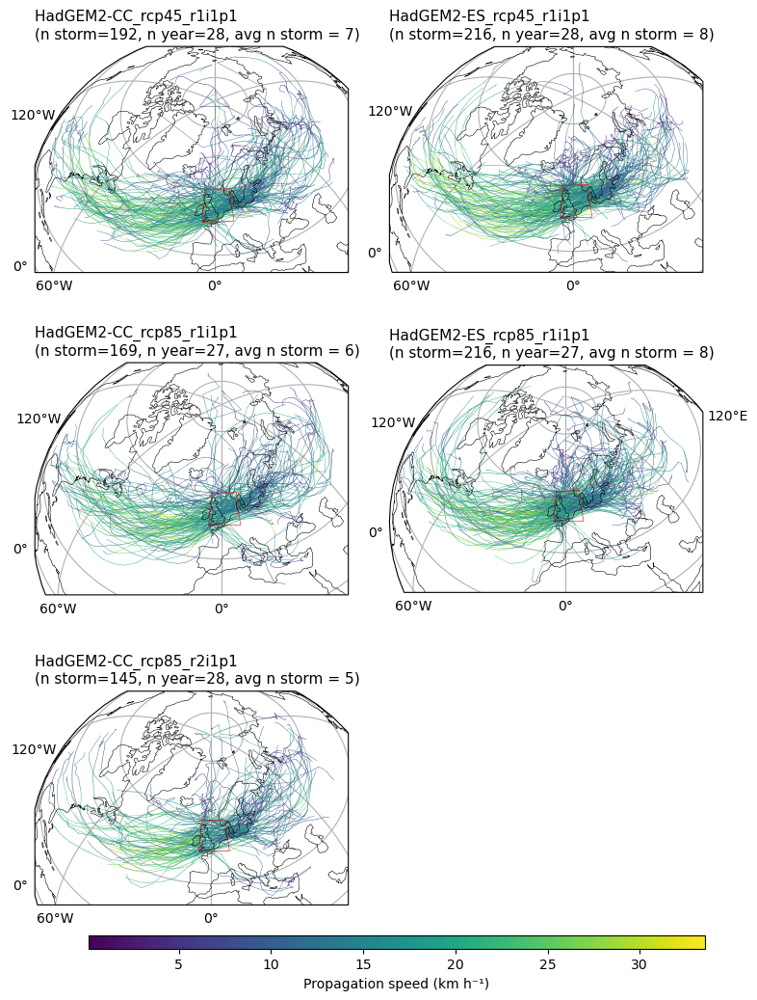

In [296]:
plot_multiple_tracks(north_trx_list, 'speed', north_trx_title)

In [101]:
def plot_multi_dense_proj(data_list, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
    
    fig, axs = plt.subplots(2, 3, figsize=(16., 7.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=0.5, vmax=8)
    map_extent = [-90, 80, 25, 90]
    
    lon = np.linspace(-180, 180, 100)
    lat = np.linspace(-90, 90, 100)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    for idx, (data, title) in enumerate(zip(data_list, fig_titles)):
        lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = plt.cm.viridis_r
        n_storm = data['uniq_id'].nunique()
        n_year = data["year"].nunique()
        avg_n_storm = n_storm / n_year 

        xy = np.vstack([lons, lats])
        kde = gaussian_kde(xy)
        z = kde(grid_coords).reshape(lon_grid.shape) * 10000
        colorvim_levels = np.arange(0.5, 8, 1)
        ax.contourf(lon_grid, lat_grid, z, norm=norm, levels=colorvim_levels, vmin=1, cmap='viridis_r', extend='max', 
                     alpha=0.8, zorder=16, transform=datacrs)

        ax.set_extent(map_extent, crs=datacrs)
        ax.set_title(title + f"\n(n storm={n_storm}, n year={n_year}, avg n storm = {avg_n_storm:.0f})", fontsize=10, loc='left')

    if len(data_list) < len(axs):
        fig.delaxes(axs[-1])

    cbar_ax = fig.add_axes([0.31, -0.030, 0.4, 0.03])
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Density (×10⁻⁴)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

In [19]:
north_trx_proj = [north_trx_CC_rcp45_r1i1p1,
                  north_trx_CC_rcp85_r1i1p1,
                  north_trx_CC_rcp85_r2i1p1,
                  north_trx_ES_rcp45_r1i1p1,
                  north_trx_ES_rcp85_r1i1p1]
north_trx_hist = [north_trx_CC_hist_r1i1p1, 
                  north_trx_CC_hist_r1i1p1,
                  north_trx_CC_hist_r2i1p1, 
                  north_trx_ES_hist_r1i1p1,
                  north_trx_ES_hist_r1i1p1]
fig_title_bias = ['HadGEM2-CC_rcp45_r1i1p1', 
                   'HadGEM2-CC_rcp85_r1i1p1', 
                   'HadGEM2-CC_rcp85_r2i1p1',
                   'HadGEM2-ES_rcp45_r1i1p1',
                    'HadGEM2-ES_rcp85_r1i1p1', 
                    ]

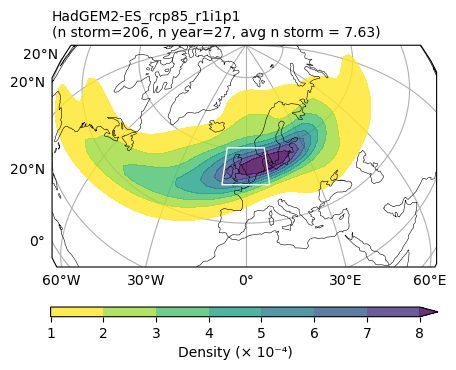

In [88]:
plot_density(north_trx_proj[4], 'vor', f'{fig_title_bias[4]}')

/tmp/ipykernel_924/1580408171.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


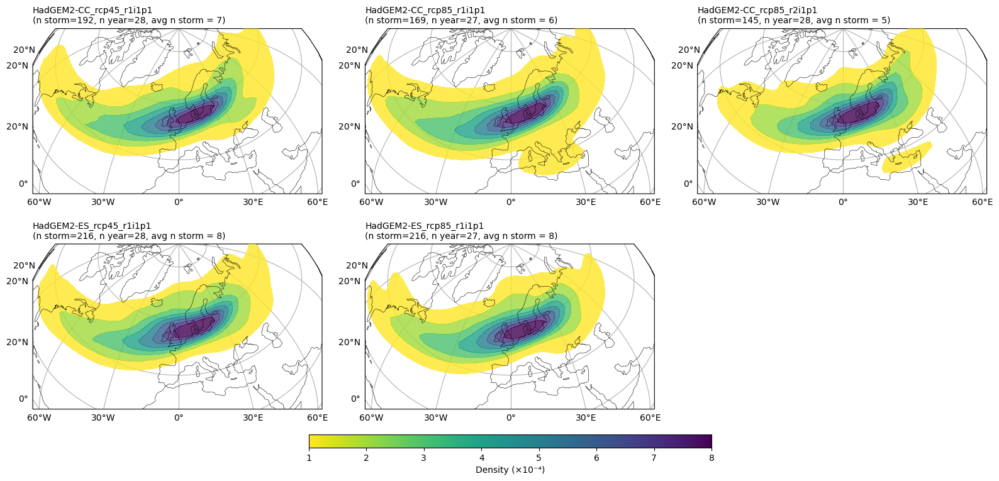

In [103]:
plot_multi_dense_proj(north_trx_list, 'vor', north_trx_title)

## Future Changes

In [110]:
def plot_multiple_bias(data_hist, data_proj, var, fig_titles):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
    
    fig, axs = plt.subplots(2, 3, figsize=(16., 7.), subplot_kw={'projection': mapcrs})
    axs = axs.flatten()
    norm = mcolors.Normalize(vmin=-5, vmax=5)
    map_extent = [-90, 80, 25, 90]
    lon = np.linspace(-180, 180, 180)
    lat = np.linspace(-90, 90, 90)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    for idx, (data_a, data_b, title) in enumerate(zip(data_hist, data_proj, fig_titles)):
        ax = axs[idx]
        ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
        gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
        gl.top_labels = False
        gl.right_labels = False
        cmap = cmaps.GreenMagenta16_r

        lons_m = data_b[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats_m = data_b[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        xy_m = np.vstack([lons_m, lats_m])
        kde_m = gaussian_kde(xy_m)
        z_m = kde_m(grid_coords).reshape(lon_grid.shape)
        z_m[z_m < 0.0002] = np.nan

        lons_e = data_a[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
        lats_e = data_a[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
        xy_e = np.vstack([lons_e, lats_e])
        kde_e = gaussian_kde(xy_e)
        z_e = kde_e(grid_coords).reshape(lon_grid.shape)
        z_e[z_e < 0.0002] = np.nan

        bias = (z_m - z_e)* 10000 
        levels = np.arange(-2.5, 2.75, 0.25)
        
        ax.pcolormesh(lon_grid, lat_grid, bias, cmap=cmaps.GreenMagenta16_r, shading='auto', 
                     alpha=0.8, zorder=16, transform=datacrs, vmin=np.nanmin(levels), vmax=np.nanmax(levels))
        ax.set_aspect('equal')
        ax.set_extent(map_extent, crs=datacrs)
        ax.set_title(title, fontsize=10, loc='left')

    if len(data_hist) < len(axs):
        fig.delaxes(axs[-1])

    #cbar_ax = fig.add_axes([0.28, 0.135, 0.4, 0.03])
    cbar_ax = fig.add_axes([0.31, -0.030, 0.4, 0.03])
    cbar = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Density Change (×10⁻⁴)")

    plt.tight_layout()#(rect=[0, 0, 0.9, 1])
    plt.show()

/tmp/ipykernel_924/2361066100.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()#(rect=[0, 0, 0.9, 1])


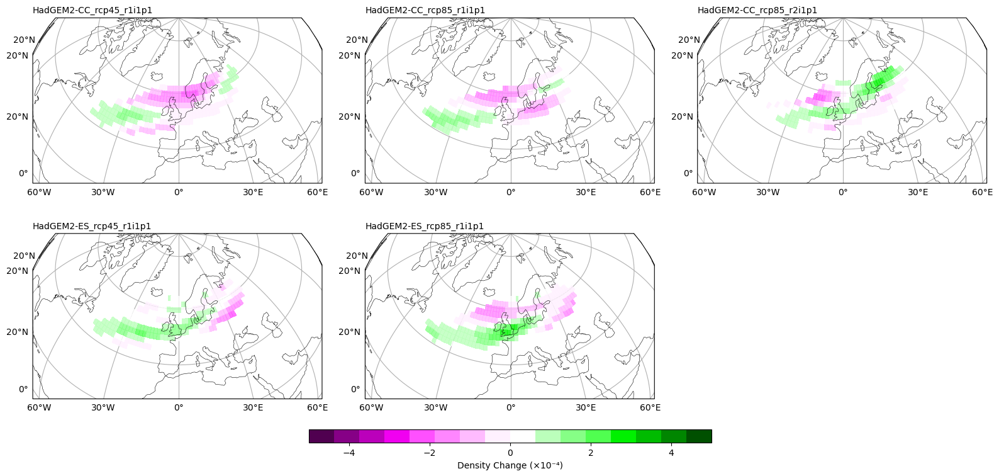

In [111]:
plot_multiple_bias(north_trx_hist, north_trx_proj, 'vor', fig_title_bias)

In [84]:
def plot_density_change (data,  data_era, var, fig_title):
    lons = data[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats = data[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    lons_e = data_era[f'lon_{var}'].apply(lambda lon: ((lon + 180) % 360) - 180)
    lats_e = data_era[f'lat_{var}'].apply(lambda lat: np.clip(lat, -90, 90))
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=55)
    map_extent = [-90, 80, 25, 90]
    
    fig, ax = plt.subplots(figsize=(5., 4.), subplot_kw={'projection': mapcrs})
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, zorder=17, linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    lon = np.linspace(-180, 180, 360)
    lat = np.linspace(-90, 90, 180)
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    grid_coords = np.vstack([lon_grid.ravel(), lat_grid.ravel()])

    xy = np.vstack([lons, lats])
    kde = gaussian_kde(xy)
    z = kde(grid_coords).reshape(lon_grid.shape)
    z[z < 0.0002] = np.nan

    xy_e = np.vstack([lons_e, lats_e])
    kde_e = gaussian_kde(xy_e)
    z_e = kde_e(grid_coords).reshape(lon_grid.shape)
    z_e[z_e < 0.0002] = np.nan
    bias = (z - z_e) * 10000    

    levels = np.arange(-5, 5, 0.5)
    #sc = ax.contourf(lon_grid, lat_grid, bias, cmap='BrBG', levels=colorvim_levels, extend='both', 
    #                 alpha=0.8, zorder=16, transform=datacrs)

    sc = ax.pcolormesh(lon_grid, lat_grid, bias, cmap=cmaps.GreenMagenta16_r, shading='auto', 
                     alpha=0.8, zorder=16, transform=datacrs, vmin=np.nanmin(levels), vmax=np.nanmax(levels))

    #ax.set_aspect('equal')
    #cbar = plt.colorbar(sc, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
    cbar = plt.colorbar(sc, ax=ax, boundaries=levels, pad=0.13, aspect=40, orientation='horizontal', extend='both')
    cbar.set_label('Density Change (×10⁻⁴)')
    cbar.set_ticks([-4, -3, -2, -1, 0, 1, 2, 3, 4])
    cbar.set_ticklabels([-4, -3, -2, -1, 0, 1, 2, 3, 4])
    ax.set_title('\n'+fig_title, fontsize=10, loc='left')
    plt.show()

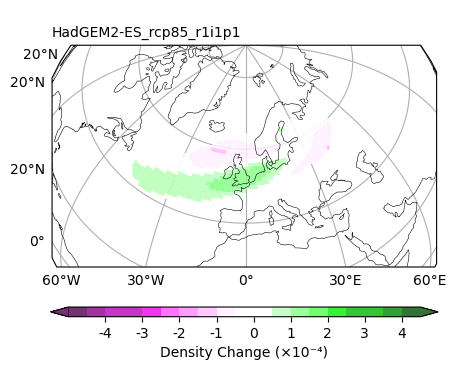

In [85]:
plot_density_change(north_trx_proj[4], north_trx_hist[4],  'vor', fig_title_bias[4])

In [21]:
freq_north_trx_CC_rcp45_r1i1p1 = north_trx_CC_rcp45_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_CC_rcp45_r1i1p1 = freq_north_trx_CC_rcp45_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_CC_rcp45_r1i1p1 = year_freq_north_trx_CC_rcp45_r1i1p1.values.tolist()

freq_north_trx_CC_rcp85_r1i1p1 = north_trx_CC_rcp85_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_CC_rcp85_r1i1p1 = freq_north_trx_CC_rcp85_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_CC_rcp85_r1i1p1 = year_freq_north_trx_CC_rcp85_r1i1p1.values.tolist()

freq_north_trx_CC_rcp85_r2i1p1 = north_trx_CC_rcp85_r2i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_CC_rcp85_r2i1p1 = freq_north_trx_CC_rcp85_r2i1p1['year'].value_counts().sort_index()
year_freq_north_trx_CC_rcp85_r2i1p1 = year_freq_north_trx_CC_rcp85_r2i1p1.values.tolist()

freq_north_trx_ES_rcp45_r1i1p1 = north_trx_ES_rcp45_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_ES_rcp45_r1i1p1 = freq_north_trx_ES_rcp45_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_ES_rcp45_r1i1p1 = year_freq_north_trx_ES_rcp45_r1i1p1.values.tolist()

freq_north_trx_ES_rcp85_r1i1p1 = north_trx_ES_rcp85_r1i1p1.drop_duplicates(subset=['uniq_id'])
year_freq_north_trx_ES_rcp85_r1i1p1 = freq_north_trx_ES_rcp85_r1i1p1['year'].value_counts().sort_index()
year_freq_north_trx_ES_rcp85_r1i1p1 = year_freq_north_trx_ES_rcp85_r1i1p1.values.tolist()

year_freq_proj = [year_freq_north_trx_CC_rcp45_r1i1p1, year_freq_north_trx_CC_rcp85_r1i1p1, 
                  year_freq_north_trx_CC_rcp85_r2i1p1,
                 year_freq_north_trx_ES_rcp45_r1i1p1, year_freq_north_trx_ES_rcp85_r1i1p1]


In [354]:
cc_r1_list = [year_freq_north_trx_CC_r1i1p1, year_freq_north_trx_CC_rcp45_r1i1p1, year_freq_north_trx_CC_rcp85_r1i1p1]
cc_r2_list = [year_freq_north_trx_CC_r2i1p1, year_freq_north_trx_CC_rcp85_r2i1p1]
es_r1_list = [year_freq_north_trx_ES_r1i1p1, year_freq_north_trx_ES_rcp45_r1i1p1, year_freq_north_trx_ES_rcp85_r1i1p1]
label_CCr1 = ['hist', 'rcp4.5', 'rcp8.5']
label_CCr2 = ['hist', 'rcp8.5']
label_ESr1 = ['hist', 'rcp4.5', 'rcp8.5']

list_plott = [cc_r1_list, cc_r2_list, es_r1_list]
list_label = [label_CCr1, label_CCr2, label_ESr1]
color_CCr1 = ['yellowgreen', 'orange', 'firebrick']
color_CCr2 = ['yellowgreen', 'firebrick']
color_ESr1 = ['yellowgreen', 'orange', 'firebrick']
coloret = [color_CCr1, color_CCr2, color_ESr1]

title_list = ['HadGEM2 CC r1i1p1', 'HadGEM2 CC r2i1p1', 'HadGEM2 ES r1i1p1']

In [370]:
for i in cc_r1_list: 
    print(np.mean(i))

6.517241379310345
6.464285714285714
6.074074074074074


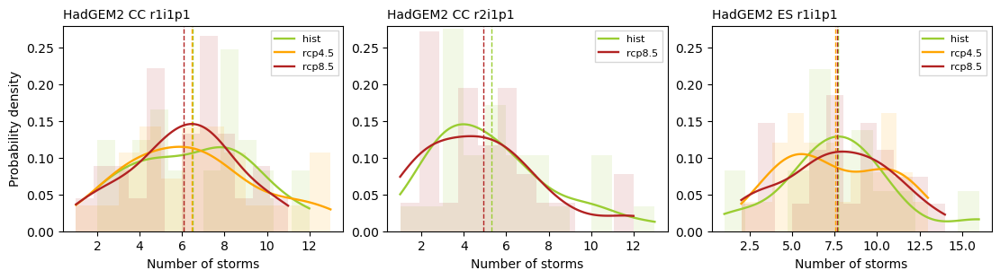

In [372]:
fig, axs = plt.subplots(1, 3, figsize=(11., 3.), constrained_layout=True)
axs = axs.flatten()

# Iterate over models (cc_r1, cc_r2, es_r1)
for j, (model_list, model_label, model_color, titles) in enumerate(zip(list_plott, list_label, coloret, title_list)):
    # Iterate over the different datasets within each model
    axs[0].set_ylabel('Probability density')
    for i, data in enumerate(model_list):
        meandat = np.mean(data)
        kde_trx = gaussian_kde(data)
        x_trx = np.linspace(min(data), max(data), 100)
        kde_values_trx = kde_trx(x_trx)
        mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
        var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
        std_trx = np.sqrt(var_trx)

        axs[j].hist(data, bins=12, density=True, alpha=0.12, color=model_color[i])#, label=model_label[i])
        axs[j].plot(x_trx, kde_values_trx, label=f'{model_label[i]}', color=model_color[i], linewidth=1.7)
        axs[j].vlines(meandat, 0, 0.28, color=model_color[i], linewidth=1, linestyle='--')
        axs[j].set_ylim(0,0.28)
        axs[j].set_xlabel('Number of storms')
        #axs[j].set_ylabel('Probability density')
        axs[j].set_title(titles,loc='left', fontsize=10)
        #axs[j].set_title(titles + f'\n μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
        axs[j].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8, ncols=1)
    #axs[0].vlines(5.89, 0, 0.28, color='yellowgreen', linewidth=1, linestyle='--')
    #axs[2].vlines(7.15, 0, 0.28, color='yellowgreen', linewidth=1, linestyle='--')

plt.show()


In [99]:
CC_r1 = [north_trx_CC_hist_r1i1p1, north_trx_CC_rcp45_r1i1p1, north_trx_CC_rcp85_r1i1p1]
CC_r2 = [north_trx_CC_hist_r2i1p1, north_trx_CC_rcp85_r2i1p1]
ES_r1 = [north_trx_ES_hist_r1i1p1, north_trx_ES_rcp45_r1i1p1, north_trx_ES_rcp85_r1i1p1]

list_data_pr = [CC_r1, CC_r2, ES_r1]

/tmp/ipykernel_897/1924458948.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


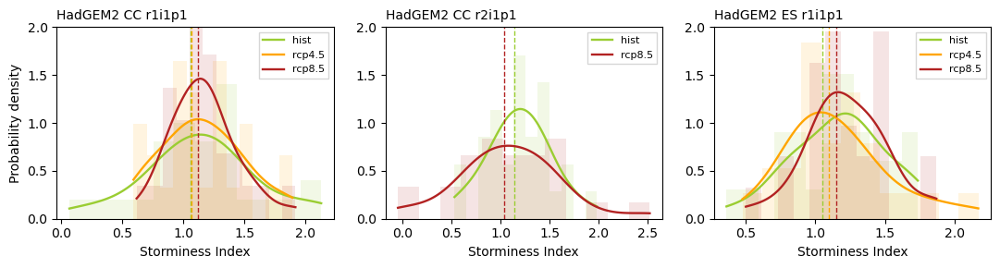

In [103]:
fig, axs = plt.subplots(1, 3, figsize=(11., 3.), constrained_layout=True)
axs = axs.flatten()

# Iterate over models (cc_r1, cc_r2, es_r1)
for j, (model_list, model_label, model_color, titles) in enumerate(zip(list_data_pr, list_label, coloret, title_list)):
    axs[0].set_ylabel('Probability density')
    for i, data in enumerate(model_list):
        vor_per = data.groupby('year')['var_mslp'].apply(lambda x: x.quantile(0.9))
        vor_mean = data['var_mslp'].mean()
        vor_std = data['var_mslp'].std()
        ssi = (vor_per.values - vor_mean) / vor_std

        kde_trx = gaussian_kde(ssi)
        x_trx = np.linspace(min(ssi), max(ssi), 100)
        kde_values_trx = kde_trx(x_trx)
        mean_trx = np.sum(x_trx * kde_values_trx) * (x_trx[1] - x_trx[0])
        var_trx = np.sum((x_trx - mean_trx)**2 * kde_values_trx) * (x_trx[1] - x_trx[0])
        std_trx = np.sqrt(var_trx)

        # Plotting on the j-th axis, which corresponds to the model (cc_r1, cc_r2, es_r1)
        axs[j].hist(ssi, bins=12, density=True, alpha=0.12, color=model_color[i])#, label=model_label[i])
        axs[j].plot(x_trx, kde_values_trx, label=f'{model_label[i]}', color=model_color[i], linewidth=1.7)
        axs[j].vlines(mean_trx, 0, 2, color=model_color[i], linewidth=1, linestyle='--')
        axs[j].set_ylim(0,2)
        axs[j].set_xlabel('Storminess Index')
        axs[j].set_title(titles, loc='left', fontsize=10)
        #axs[j].set_title(titles + f'\n μ= {mean_trx:.2f}, σ= {std_trx:.2f}, σ²= {var_trx:.2f}', fontsize=10, loc='left')
        axs[j].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8, ncols=1)

plt.tight_layout()
plt.show()

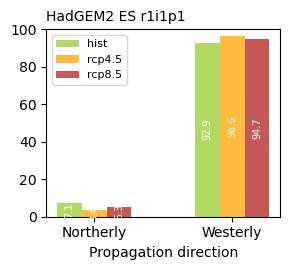

In [212]:
CC_r1 = [north_trx_CC_hist_r1i1p1, north_trx_CC_rcp45_r1i1p1, north_trx_CC_rcp85_r1i1p1]
CC_r2 = [north_trx_CC_hist_r2i1p1, north_trx_CC_rcp85_r2i1p1]
ES_r1 = [north_trx_ES_hist_r1i1p1, north_trx_ES_rcp45_r1i1p1, north_trx_ES_rcp85_r1i1p1]

label_CCr1 = ['hist', 'rcp4.5', 'rcp8.5']
label_CCr2 = ['hist', 'rcp8.5']
label_ESr1 = ['hist', 'rcp4.5', 'rcp8.5']

list_plott = [cc_r1_list, cc_r2_list, es_r1_list]
list_label = [label_CCr1, label_CCr2, label_ESr1]
color_CCr1 = ['yellowgreen', 'orange', 'firebrick']
color_CCr2 = ['yellowgreen', 'firebrick']
color_ESr1 = ['yellowgreen', 'orange', 'firebrick']


title_list = ['HadGEM2 CC r1i1p1', 'HadGEM2 CC r2i1p1', 'HadGEM2 ES r1i1p1']

datasets = ES_r1
colort=color_ESr1
ahlabel = label_ESr1
# Calculate the percentage of storms for northerly and westerly directions for each dataset
percentages = []
for data in datasets:
    crop_storm = data.drop_duplicates(subset=['uniq_id'])
    dir_count = crop_storm['category'].value_counts().sort_index()
    dir_count = (dir_count / dir_count.sum()) * 100
    percentages.append(dir_count)

# Create a grouped bar chart
directions = ['Northerly', 'Westerly']
x = range(len(directions))
width = 0.18  # width of the bars

fig, ax = plt.subplots(figsize=(3., 2.8))

# Plot each dataset's bars
for i, percent in enumerate(percentages):
    ax.bar([p + i * width for p in x], [percent.get('Northerly', 0), percent.get('Westerly', 0)], 
           width=width, color=colort[i], alpha=0.75, label=ahlabel[i])
for container in ax.containers: 
    ax.bar_label(container,fmt='%.1f', label_type='center', fontsize=7, color='white', rotation=90)

ax.set_ylim(0,100)
ax.set_xlabel('Propagation direction')
#ax.set_ylabel('Percentage of storms (%)')
ax.set_xticks([p + 1 * width for p in x])
ax.set_xticklabels(directions)
ax.legend(loc='best', fontsize=8)
ax.set_title(title_list[2], fontsize=10, loc='left')

plt.tight_layout()
plt.show()


### Meteorological Prop

In [25]:
color_CCr1 = ['yellowgreen', 'orange', 'firebrick']
color_CCr2 = ['yellowgreen', 'firebrick']
color_ESr1 = ['yellowgreen', 'orange', 'firebrick']

In [294]:
datasets = [north_trx_CC_hist_r1i1p1, north_trx_CC_rcp45_r1i1p1, north_trx_CC_rcp85_r1i1p1,
            north_trx_CC_hist_r2i1p1, north_trx_CC_rcp85_r2i1p1,
            north_trx_ES_hist_r1i1p1, north_trx_ES_rcp45_r1i1p1, north_trx_ES_rcp85_r1i1p1]

new_north = []

for dataset in datasets:
    northsea_bound = dataset[(dataset['lon_vor'] >= -10) & (dataset['lon_vor'] <= 10) & 
                             (dataset['lat_vor'] >= 50) & (dataset['lat_vor'] <= 60)]
    
    new_north.append(northsea_bound)
"""
new_north = [new_north_trx_CC_hist_r1i1p1, new_north_trx_CC_rcp45_r1i1p1, new_north_trx_CC_rcp85_r1i1p1,
            new_north_trx_CC_hist_r2i1p1, new_north_trx_CC_rcp85_r2i1p1,
            new_north_trx_CC_hist_r2i1p1, new_north_trx_ES_rcp45_r1i1p1, new_north_trx_ES_rcp85_r1i1p1]
"""
new_north_trx_CC_hist_r1i1p1 =  new_north[0]
new_north_trx_CC_rcp45_r1i1p1 =  new_north[1]
new_north_trx_CC_rcp85_r1i1p1 =  new_north[2]
new_north_trx_CC_hist_r2i1p1 =  new_north[3]
new_north_trx_CC_rcp85_r2i1p1 =  new_north[4]
new_north_trx_ES_hist_r1i1p1 =  new_north[5]
new_north_trx_ES_rcp45_r1i1p1 =  new_north[6]
new_north_trx_ES_rcp85_r1i1p1 =  new_north[7]

In [373]:
datasets_hist = [new_north_trx_CC_hist_r1i1p1, new_north_trx_CC_hist_r2i1p1, new_north_trx_ES_hist_r1i1p1]
datasets_rcp45 = [new_north_trx_CC_rcp45_r1i1p1, new_north_trx_ES_rcp45_r1i1p1]
datasets_rcp85 = [new_north_trx_CC_rcp85_r1i1p1, new_north_trx_CC_rcp85_r2i1p1, new_north_trx_ES_rcp85_r1i1p1]

variables = ['speed', 'var_vor', 'var_mslp', 'var_wind', 'duration']

def compute_mean(datasets, var):
    min_length = min([len(ds[var].dropna()) for ds in datasets])
    clean_data = [ds[var].dropna().values[:min_length] for ds in datasets]
    mean_data = np.mean(clean_data, axis=0)
    return mean_data

mean_results = {}

for var in variables:
    mean_results[f'{var}_hist_mean'] = compute_mean(datasets_hist, var)
    mean_results[f'{var}_rcp45_mean'] = compute_mean(datasets_rcp45, var)
    mean_results[f'{var}_rcp85_mean'] = compute_mean(datasets_rcp85, var)

/tmp/ipykernel_575/2665296553.py:67: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


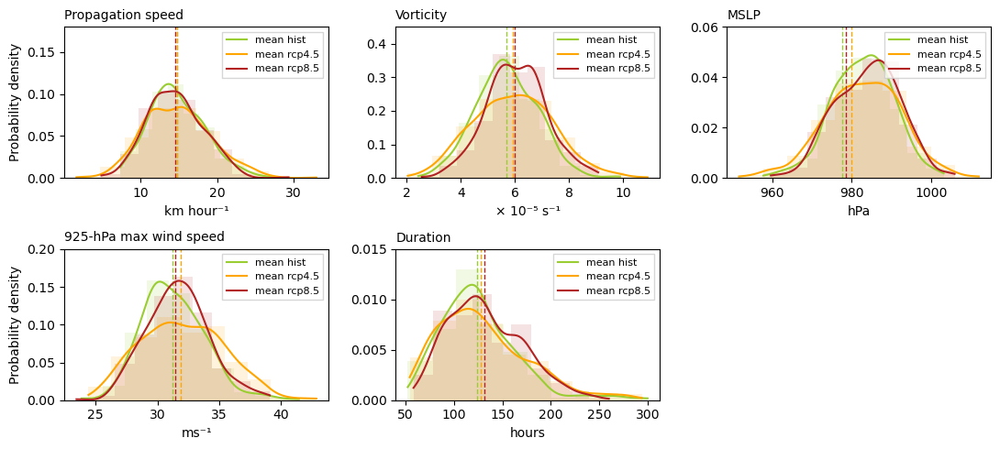

In [318]:
plot_data = {
    'speed': ['speed_hist_mean', 'speed_rcp45_mean', 'speed_rcp85_mean'],
    'vor': ['var_vor_hist_mean', 'var_vor_rcp45_mean', 'var_vor_rcp85_mean'],
    'msl': ['var_mslp_hist_mean', 'var_mslp_rcp45_mean', 'var_mslp_rcp85_mean'],
    'wind': ['var_wind_hist_mean', 'var_wind_rcp45_mean', 'var_wind_rcp85_mean'],
    'dur': ['duration_hist_mean', 'duration_rcp45_mean', 'duration_rcp85_mean']
}

colorset = ['yellowgreen', 'orange', 'firebrick']
dataset_labels = ['mean hist', 'mean rcp4.5', 'mean rcp8.5']

titles = ['Propagation speed', 'Vorticity', 'MSLP', '925-hPa max wind speed', 'Duration']
ylabels = ['km hour⁻¹', '× 10⁻⁵ s⁻¹', 'hPa', 'ms⁻¹', 'hours']

fig, axs = plt.subplots(2, 3, figsize=(11, 5), constrained_layout=True)
axs = axs.flatten()

for i, (key, value) in enumerate(plot_data.items()):
    ax = axs[i]  
    for j, scenario_key in enumerate(value):
        var = mean_results[scenario_key]

        kde = gaussian_kde(var)
        x_grid = np.linspace(min(var), max(var), 1000)
        kde_vals = kde(x_grid)
        mean_val = np.sum(x_grid * kde_vals) * (x_grid[1] - x_grid[0])
        var_val = np.sum((x_grid - mean_val)**2 * kde_vals) * (x_grid[1] - x_grid[0])
        std_val = np.sqrt(var_val)

        ax.hist(var, bins=10, density=True, alpha=0.13, color=colorset[j])
        ax.plot(x_grid, kde_vals, color=colorset[j], linewidth=1.5, label=f'{dataset_labels[j]}')
        ax.vlines(mean_val, 0, 0.48, color=colorset[j], linewidth=1, linestyle='--')

    ax.set_title(titles[i], loc='left', fontsize=10)
    ax.set_xlabel(ylabels[i])
    if i in [0, 3]:
        ax.set_ylabel('Probability density')

    if i == 0:
        ax.set_ylim(0, 0.18)
    elif i == 1:
        ax.set_ylim(0, 0.45)
    elif i == 2:
        ax.set_ylim(0, 0.06)
    elif i == 3:
        ax.set_ylim(0, 0.2)
    elif i == 4:
        ax.set_ylim(0, 0.015)

    ax.legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8, ncols=1)

for ax in axs[len(plot_data):]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


In [239]:
CC_r1 = [north_trx_CC_hist_r1i1p1, north_trx_CC_rcp45_r1i1p1, north_trx_CC_rcp85_r1i1p1]
CC_r2 = [north_trx_CC_hist_r2i1p1, north_trx_CC_rcp85_r2i1p1]
ES_r1 = [north_trx_ES_hist_r1i1p1, north_trx_ES_rcp45_r1i1p1, north_trx_ES_rcp85_r1i1p1]
list_plot = [CC_r1, CC_r2, ES_r1]

label_CCr1 = ['hist', 'rcp4.5', 'rcp8.5']
label_CCr2 = ['hist', 'rcp8.5']
label_ESr1 = ['hist', 'rcp4.5', 'rcp8.5']
list_label = [label_CCr1, label_CCr2, label_ESr1]

color_CCr1 = ['yellowgreen', 'orange', 'firebrick']
color_CCr2 = ['yellowgreen', 'firebrick']
color_ESr1 = ['yellowgreen', 'orange', 'firebrick']
list_color = [color_CCr1, color_CCr2, color_ESr1]

/tmp/ipykernel_575/897710956.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


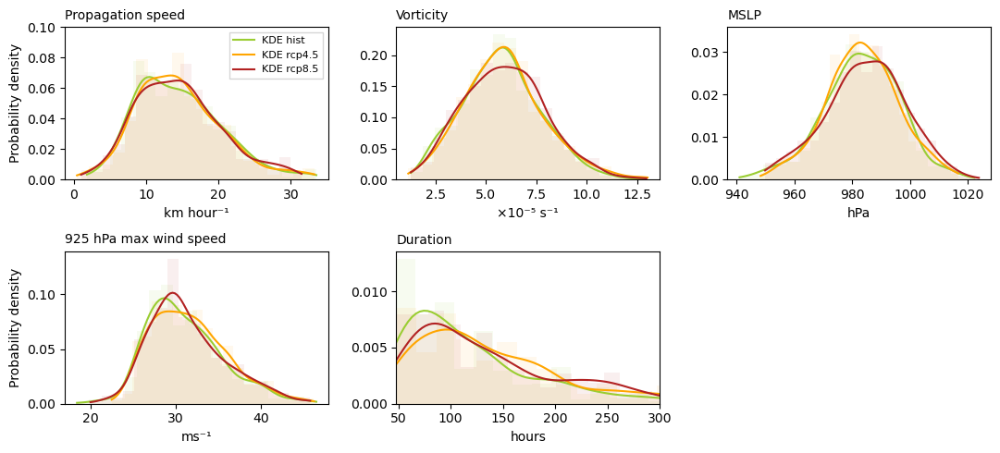

In [245]:
fig, axs = plt.subplots(2, 3, figsize=(11., 5.), constrained_layout=True)
axs = axs.flatten()

for i, datax in enumerate (CC_r1):
        northsea_bound = datax[(datax['lon_vor'] >= -10) & (datax['lon_vor'] <= 10) & 
                                (datax['lat_vor'] >= 50) & (datax['lat_vor'] <= 60)]

        kde_speed = gaussian_kde(northsea_bound['speed'])
        x_grid_speed = np.linspace(min(northsea_bound['speed']), max(northsea_bound['speed']), 100)
        kde_val_speed = kde_speed(x_grid_speed)
        mean_speed = np.sum(x_grid_speed * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
        var_speed = np.sum((x_grid_speed - mean_speed)**2 * kde_val_speed) * (x_grid_speed[1] - x_grid_speed[0])
        std_speed = np.sqrt(var_speed)

        kde_vor = gaussian_kde(northsea_bound['var_vor'])
        x_grid_vor = np.linspace(min(northsea_bound['var_vor']), max(northsea_bound['var_vor']), 100)
        kde_val_vor = kde_vor(x_grid_vor)
        mean_vor = np.sum(x_grid_vor * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
        var_vor = np.sum((x_grid_vor - mean_vor)**2 * kde_val_vor) * (x_grid_vor[1] - x_grid_vor[0])
        std_vor = np.sqrt(var_vor)

        kde_mslp = gaussian_kde(northsea_bound['var_mslp'])
        x_grid_mslp = np.linspace(min(northsea_bound['var_mslp']), max(northsea_bound['var_mslp']), 100)
        kde_val_mslp = kde_mslp(x_grid_mslp)
        mean_mslp = np.sum(x_grid_mslp * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
        var_mslp = np.sum((x_grid_mslp - mean_mslp)**2 * kde_val_mslp) * (x_grid_mslp[1] - x_grid_mslp[0])
        std_mslp = np.sqrt(var_mslp)

        kde_wind = gaussian_kde(northsea_bound['var_wind'])
        x_grid_wind = np.linspace(min(northsea_bound['var_wind']), max(northsea_bound['var_wind']), 100)
        kde_val_wind = kde_wind(x_grid_wind)
        mean_wind = np.sum(x_grid_wind * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
        var_wind = np.sum((x_grid_wind - mean_wind)**2 * kde_val_wind) * (x_grid_wind[1] - x_grid_wind[0])
        std_wind = np.sqrt(var_wind)

        kde_dur = gaussian_kde(northsea_bound['duration'])
        x_grid_dur = np.linspace(min(northsea_bound['duration']), max(northsea_bound['duration']), 100)
        kde_val_dur = kde_dur(x_grid_dur)
        mean_dur = np.sum(x_grid_dur * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
        var_dur = np.sum((x_grid_dur - mean_dur)**2 * kde_val_dur) * (x_grid_dur[1] - x_grid_dur[0])
        std_dur = np.sqrt(var_dur)
        dataset_labels = label_CCr1
        colorset = color_CCr1
        axs[0].hist(northsea_bound['speed'], bins=20, density=True, alpha=0.07, color=colorset[i])
        axs[0].plot(x_grid_speed, kde_val_speed, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        #axs[0].set_title(f'μ= {mean_speed:.2f}, σ= {std_speed:.2f}, σ²= {var_speed:.2f}', fontsize=10, loc='left')
        axs[0].set_title('Propagation speed', loc='left', fontsize=10)
        axs[0].set_ylim(0,0.1)
        axs[0].set_xlabel('km hour⁻¹')
        axs[0].set_ylabel('Probability density')
        axs[0].legend(fancybox=False, framealpha=None, loc='upper right', fontsize=8, ncols=1)
        axs[1].hist(northsea_bound['var_vor'], bins=20, density=True, alpha=0.07, color=colorset[i])
        axs[1].plot(x_grid_vor, kde_val_vor, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        #axs[1].set_title(f'{μ= {mean_vor:.2f}, σ= {std_vor:.2f}, σ²= {var_vor:.2f}', fontsize=10, loc='left')
        axs[1].set_title('Vorticity', loc='left', fontsize=10)
        axs[1].set_xlabel('×10⁻⁵ s⁻¹')
        axs[2].hist(northsea_bound['var_mslp'], bins=20, density=True, alpha=0.07, color=colorset[i])
        axs[2].plot(x_grid_mslp, kde_val_mslp, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[2].set_title('MSLP', loc='left', fontsize=10)
        axs[2].set_xlabel('hPa')
        axs[3].set_ylabel('Probability density')
        axs[3].hist(northsea_bound['var_wind'], bins=20, density=True, alpha=0.07, color=colorset[i])
        axs[3].plot(x_grid_wind, kde_val_wind, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[3].set_title('925 hPa max wind speed', loc='left', fontsize=10)
        axs[3].set_xlabel('ms⁻¹')
        axs[4].hist(northsea_bound['duration'], bins=20, density=True, alpha=0.07, color=colorset[i])
        axs[4].plot(x_grid_dur, kde_val_dur, label=f'KDE {dataset_labels[i]}', color=colorset[i], linewidth=1.5)
        axs[4].set_title('Duration', loc='left', fontsize=10)
        axs[4].set_xlim(48,300)
        axs[4].set_xlabel('hours')
        #axs[4].legend(fontsize=8, fancybox=False, loc='upper left', ncols=2, bbox_to_anchor=(1.01, 1))
        
for ax in axs[5:]:
    fig.delaxes(ax) 
   
plt.tight_layout()
plt.show()

/tmp/ipykernel_575/103356794.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


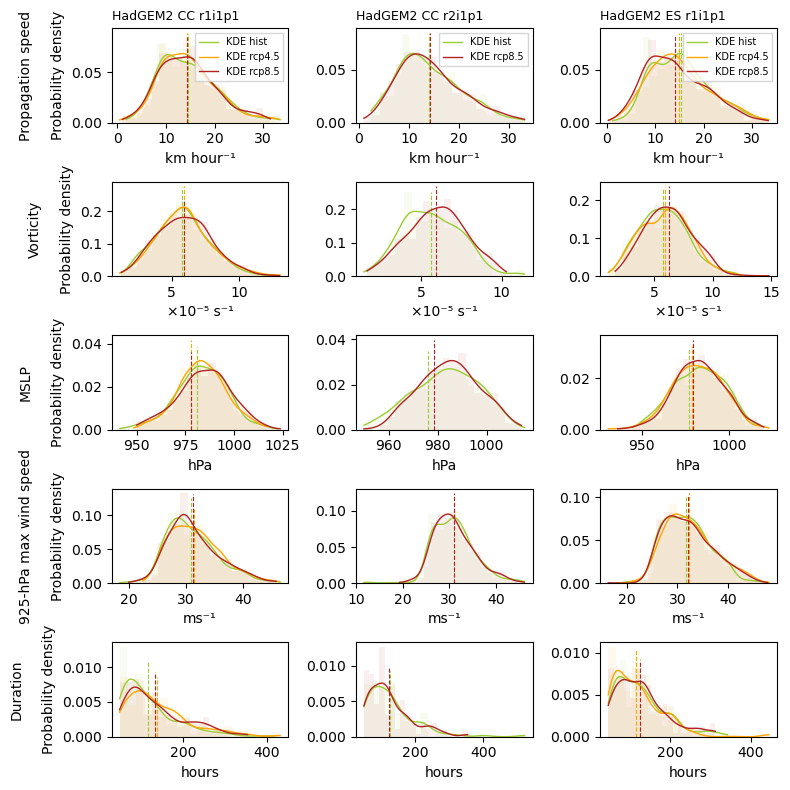

In [349]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Define data structures
variables = ['speed', 'var_vor', 'var_mslp', 'var_wind', 'duration']
titles = ['Propagation speed', 'Vorticity', 'MSLP', '925-hPa max wind speed', 'Duration']
xlabels = ['km hour⁻¹', '×10⁻⁵ s⁻¹', 'hPa', 'ms⁻¹', 'hours']

list_plot = [CC_r1, CC_r2, ES_r1]
list_label = [label_CCr1, label_CCr2, label_ESr1]
list_color = [color_CCr1, color_CCr2, color_ESr1]

# Set up the figure and subplots for a 3x5 grid
fig, axs = plt.subplots(5, 3, figsize=(8., 8.), constrained_layout=True)

# Iterate over each variable (rows)
for row_idx, var in enumerate(variables):
    # Iterate over each data subset (columns)
    for col_idx, (subset_data, labels, colors) in enumerate(zip(list_plot, list_label, list_color)):
        ax = axs[row_idx, col_idx]  # Select the current subplot

        # Loop through each scenario within the subset
        for scenario_idx, datax in enumerate(subset_data):
            # Filter the data for North Sea bounds
            northsea_bound = datax[(datax['lon_vor'] >= -10) & (datax['lon_vor'] <= 10) & 
                                   (datax['lat_vor'] >= 50) & (datax['lat_vor'] <= 60)]

            # Compute KDE for the current variable
            kde = gaussian_kde(northsea_bound[var].dropna())
            x_grid = np.linspace(min(northsea_bound[var]), max(northsea_bound[var]), 100)
            kde_vals = kde(x_grid)
            mean_val = np.sum(x_grid * kde_vals) * (x_grid[1] - x_grid[0])

            # Plot histogram and KDE for each scenario
            ax.hist(northsea_bound[var], bins=20, density=True, alpha=0.07, color=colors[scenario_idx])
            ax.plot(x_grid, kde_vals, color=colors[scenario_idx], linewidth=1, label=f'KDE {labels[scenario_idx]}')
            ax.vlines(mean_val, 0, max(kde_vals)*1.3, color=colors[scenario_idx], linewidth=0.8, linestyle='--')

        # Set titles and labels for each subplot    
        if col_idx == 0:
            ax.set_ylabel(f'{titles[row_idx]}\n\nProbability density')  # Set y-label only on the left column
        #if row_idx == 0:
            #ax.set_title(f'{labels[scenario_idx]}', loc='left', fontsize=10)  # Set title for each variable
                    # Show legend only for the first row
        if row_idx == 0:
            ax.legend(fancybox=False, framealpha=None, loc='upper right', fontsize=7, ncols=1)

        ax.set_xlabel(xlabels[row_idx])
        axs[0,0].set_title('HadGEM2 CC r1i1p1', loc='left', fontsize=9)
        axs[0,1].set_title('HadGEM2 CC r2i1p1', loc='left', fontsize=9)
        axs[0,2].set_title('HadGEM2 ES r1i1p1', loc='left', fontsize=9)

plt.tight_layout()
plt.show()


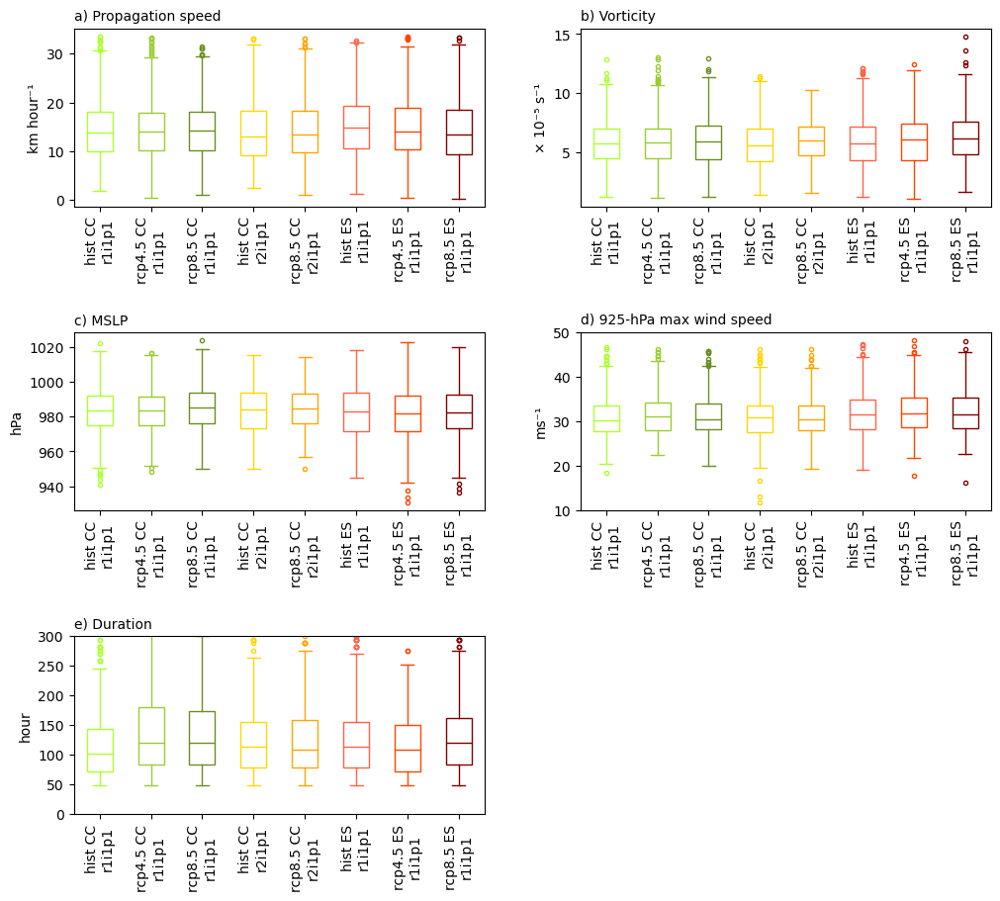

In [155]:
fig, axs = plt.subplots(3, 2, figsize=(10., 9.), constrained_layout=True, gridspec_kw={'wspace':0.1, 'hspace': 0.1})

axs = axs.flatten()
# Loop over each variable to plot
for idx, (var, title, ylabel) in enumerate(zip(variables, titles, ylabels)):
    data_to_plot = []
    for datax in datasets:
        storm_filter = datax[(datax['lat_vor'] >= 50) & (datax['lat_vor'] <= 60) &
                             (datax['lon_vor'] >= -10) & (datax['lon_vor'] <= 10)]
        if var in storm_filter.columns:
            data_to_plot.append(storm_filter[var].dropna())
    
    # Create the boxplot with consistent colors for each dataset
    box = axs[idx].boxplot(data_to_plot, patch_artist=True, labels=dataset_labels)
    
    # Apply colors to each boxplot element (boxes, whiskers, caps, fliers, medians)
    for i, (patch, color) in enumerate(zip(box['boxes'], colorset)):
        patch.set_facecolor('white')  # White face for boxes
        patch.set_edgecolor(color)    # Colored edge for boxes
        box['medians'][i].set_color(color)
        for j in range(2):  # Two whiskers and two caps per dataset
            box['whiskers'][2 * i + j].set_color(color)
            box['caps'][2 * i + j].set_color(color)
        box['fliers'][i].set(markeredgecolor=color, markersize=3)
    
    axs[idx].set_ylabel(ylabel)
    axs[idx].set_title(title, loc='left', fontsize=10)
    axs[idx].set_xticklabels(dataset_labels, rotation=90, ha='center')
    axs[3].set_ylim(10,50)
    axs[4].set_ylim(0,300)

# Remove any extra axes that don't have corresponding data
for ax in axs[len(variables):]:
    fig.delaxes(ax)

plt.show()


### Correction QM

In [ ]:
def calculate_quantile_mapping_functions(historical_model_data, historical_observed_data, num_quantiles=1000):
    model_quantiles = np.linspace(0, 1, num_quantiles)
    observed_quantiles = np.quantile(historical_observed_data, model_quantiles)
    model_quantiles_values = np.quantile(historical_model_data, model_quantiles)
    
    return model_quantiles_values, observed_quantiles

historical_observed_data = np.random.normal(loc=0, scale=1, size=1000) 
historical_model_data = np.random.normal(loc=1, scale=1.5, size=1000) 
model_quantiles_values, observed_quantiles = calculate_quantile_mapping_functions(historical_model_data, historical_observed_data)


In [ ]:
def calculate_delta_changes(historical_model_data, future_model_data, num_quantiles=1000):
    model_quantiles = np.linspace(0, 1, num_quantiles)
    historical_quantiles_values = np.quantile(historical_model_data, model_quantiles)
    future_quantiles_values = np.quantile(future_model_data, model_quantiles)
    
    deltas = future_quantiles_values - historical_quantiles_values
    return deltas

future_model_data = np.random.normal(loc=2, scale=1.5, size=1000)
deltas = calculate_delta_changes(historical_model_data, future_model_data)

In [ ]:
def apply_quantile_delta_mapping(historical_model_data, future_model_data, model_quantiles_values, observed_quantiles, deltas, num_quantiles=1000):
    corrected_future_data = np.interp(future_model_data, np.sort(future_model_data), observed_quantiles) + deltas
    return corrected_future_data

corrected_future_model_data = apply_quantile_delta_mapping(historical_model_data, future_model_data, model_quantiles_values, observed_quantiles, deltas)

observed_pdf = gaussian_kde(historical_observed_data)
historical_model_pdf = gaussian_kde(historical_model_data)
future_model_pdf = gaussian_kde(future_model_data)
corrected_future_model_pdf = gaussian_kde(corrected_future_model_data)

x = np.linspace(min(historical_observed_data.min(), future_model_data.min(), corrected_future_model_data.min()), 
                max(historical_observed_data.max(), future_model_data.max(), corrected_future_model_data.max()), 1000)

plt.figure(figsize=(10, 6))
plt.plot(x, observed_pdf(x), label='Historical Observed PDF', linestyle='-', color='blue')
plt.plot(x, historical_model_pdf(x), label='Historical Model PDF', linestyle='--', color='green')
plt.plot(x, future_model_pdf(x), label='Future Model PDF', linestyle='-.', color='red')
plt.plot(x, corrected_future_model_pdf(x), label='Corrected Future Model PDF', linestyle='-', color='purple')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Probability Density Functions')
plt.legend()
plt.grid(True)
plt.show()


### Storm Direction

In [50]:
from windrose import WindroseAxes
import matplotlib.cm as cm
def plot_windrose(df, title):
    trx_dir_all = df.dropna(subset=['bearing', 'speed'])

    northsea_bound = trx_dir_all[
        (trx_dir_all['lon_vor'] >= -4) & 
        (trx_dir_all['lon_vor'] <= 10) & 
        (trx_dir_all['lat_vor'] >= 50) & 
        (trx_dir_all['lat_vor'] <= 60)]

    trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

    # Create the windrose plot
    fig = plt.figure(figsize=(4., 4.))
    ax = WindroseAxes.from_ax(fig=fig)
    
    #ax.contour(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, 
    #           bins=np.arange(0, 45, 10), cmap=cm.Reds, lw=1, alpha=0.7, normed=True)
    ax.contour(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, 
               bins=np.arange(0, 45, 10), cmap=cm.Greens, lw=1.3, alpha=0.9, normed=True)
    
    ax.set_title('HadGEM_'+title, loc='left')
    ax.set_legend(title="Storm propagation \nspeed (km/h)", loc="lower left", fontsize=5)
    plt.show()

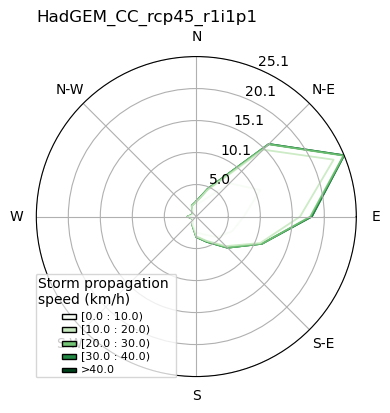

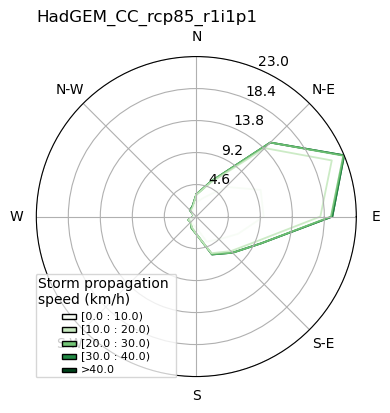

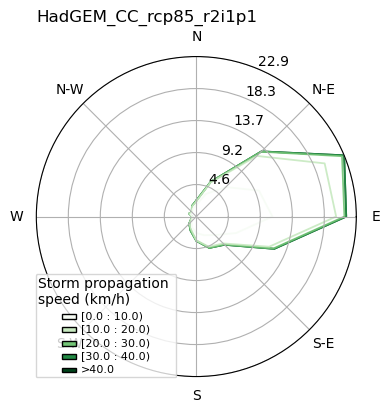

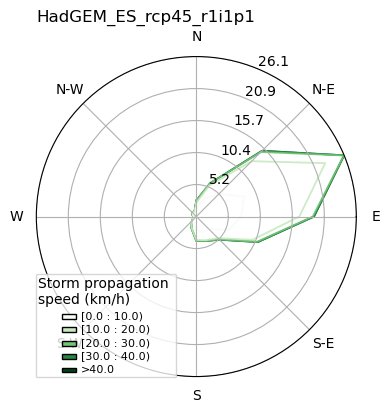

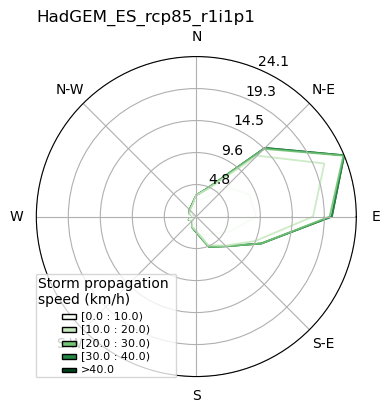

In [288]:
for i, (trx, name) in enumerate(zip(trx_list, names)):
    plot_windrose(trx, name)

In [318]:
season_counts_list = []

for trx in north_trx_list:
    # Filter storms based on latitude and longitude
    storm_filter = trx[(trx['lat_vor'] >= 50) & (trx['lat_vor'] <= 60) &
                       (trx['lon_vor'] >= -10) & (trx['lon_vor'] <= 10)]
    
    # Determine storm direction/category
    category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
    category.columns = ['uniq_id', 'category']
    
    # Merge category data back into trx
    trx = trx.merge(category, on='uniq_id', how='left')
    
    # Drop duplicates based on unique storm ID
    merged_data = trx.drop_duplicates(subset=['uniq_id'])
    
    # Count storms per year and category, ensuring consistent representation
    season_counts = merged_data.groupby(['year', 'category']).size().unstack(fill_value=0)
    
    # Ensure all expected categories are present, filling missing categories with 0
    all_categories = ['Northerly', 'Westerly']  # Include all possible categories
    for category in all_categories:
        if category not in season_counts.columns:
            season_counts[category] = 0
            
    # Reorder columns if necessary
    season_counts = season_counts.reindex(columns=all_categories)
    
    # Append to the list
    season_counts_list.append(season_counts)


/tmp/ipykernel_805/735005438.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_805/735005438.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_805/735005438.py:9: DeprecationWarning: DataFrameGroupBy.apply operated o

In [314]:
season_counts_list = []

for trx in north_trx_list:
    storm_filter = trx[(trx['lat_vor'] >= 50) & (trx['lat_vor'] <= 60) &
                       (trx['lon_vor'] >= -10) & (trx['lon_vor'] <= 10)]
    
    category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
    category.columns = ['uniq_id', 'category']
    trx = trx.merge(category, on='uniq_id', how='left')
    merged_data = trx.drop_duplicates(subset=['uniq_id'])
    season_counts = merged_data.groupby(['year', 'category']).size().unstack(fill_value=0)
    season_counts_list.append(season_counts)

/tmp/ipykernel_805/2029801853.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_805/2029801853.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  category = storm_filter.groupby('uniq_id').apply(storm_direction).reset_index()
/tmp/ipykernel_805/2029801853.py:7: DeprecationWarning: DataFrameGroupBy.apply operate

In [319]:
season_counts_list[2]

category,Northerly,Westerly
year,,
1,0,2
2,1,6
3,0,4
4,0,1
5,0,7
6,2,5
7,0,7
8,1,5
9,1,4


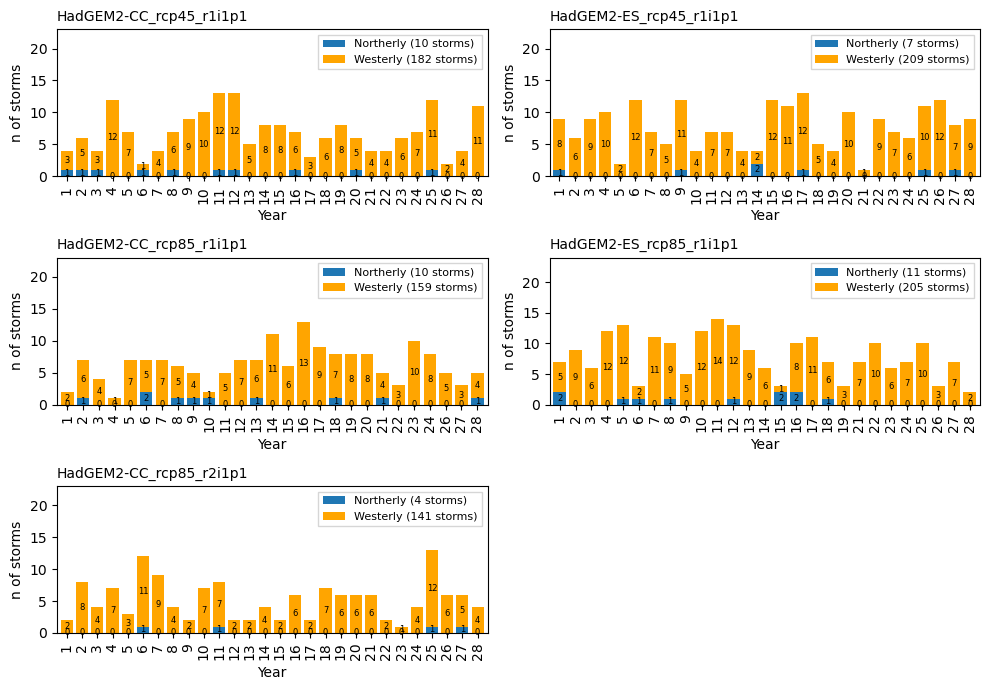

In [315]:
fig, axs = plt.subplots(3, 2, figsize=(10., 7.))
axs = axs.flatten()

for i, (data, title) in enumerate(zip(season_counts_list, north_trx_title)):
    ax = axs[i]
    colors = [color_mapping.get(col, 'tab:gray') for col in data.columns]
    data.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)
    ax.set_title(title, fontsize=10, loc='left')
    ax.set_xlabel('Year')
    ax.set_ylabel('n of storms')
    ax.set_ylim(0, max(data.sum(axis=1)) + 10)
    storm_totals = data.sum(axis=0)
    extra_text_labels = [f"{cat} ({storm_totals[cat]} storms)" for cat in season_counts.columns]
    ax.legend(labels=extra_text_labels, fancybox=False, fontsize=8)
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fontsize=6)

# Remove the unused sixth subplot (bottom right corner)
fig.delaxes(axs[5])

plt.tight_layout()
plt.show()

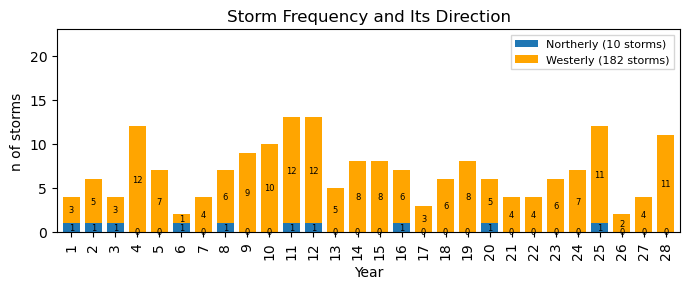

In [297]:
merged_data = trx_sam.drop_duplicates(subset=['uniq_id'])
season_counts = merged_data.groupby(['year', 'category']).size().unstack(fill_value=0)

# Create the stacked bar plot
fig, ax = plt.subplots(figsize=(7., 3.))
color_mapping = {
    'Northerly': 'tab:blue',
    'Westerly': 'orange'
}

# Apply color mapping
colors = [color_mapping.get(col, 'tab:gray') for col in season_counts.columns]
season_counts.plot(kind='bar', stacked=True, ax=ax, width=0.8, color=colors)

# Set the title and labels
ax.set_title('Storm Frequency and Its Direction')
ax.set_xlabel('Year')
ax.set_ylabel('n of storms')
ax.set_ylim(0, max(season_counts.sum(axis=1)) + 10)
storm_totals = season_counts.sum(axis=0)
extra_text_labels = [f"{cat}: (n:{storm_totals[cat]})" for cat in season_counts.columns]
plt.legend(labels=extra_text_labels, fancybox=False, fontsize=8)

for container in ax.containers:
    ax.bar_label(container, label_type='center', fontsize=6)

plt.tight_layout()
plt.show()

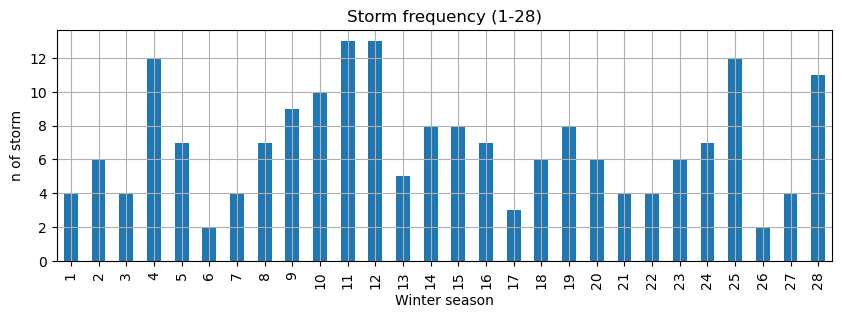

In [222]:
filtered_storm = north_trx_CC_rcp45_r1i1p1.drop_duplicates(subset=['uniq_id'])
season_counts = filtered_storm['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10., 3.))
season_counts.plot(kind='bar', color='tab:blue')
plt.title('Storm frequency (1-28)')
plt.xlabel('Winter season')
plt.ylabel('n of storm')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

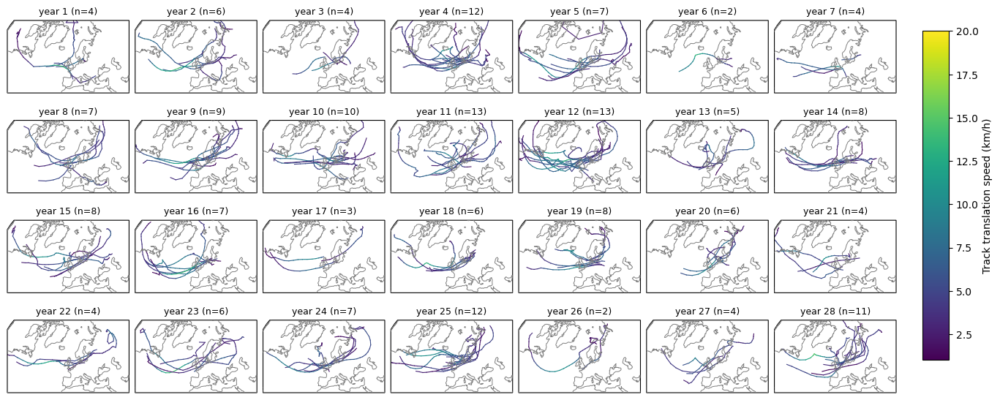

In [245]:
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

datacrs = ccrs.PlateCarree()
mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)
boundary = [-80, 60, 90, 30]

fig, axs = plt.subplots(4, 7, sharey=True, sharex=True, figsize=(18., 6.), subplot_kw={'projection': mapcrs})
axs = axs.ravel()

for iyear, ax in enumerate(axs):
    year = 1 + iyear
    trx_season = trx_sam[trx_sam['year'] == year]
    if trx_season.empty:
        continue

    season = trx_season['year'].iloc[0]
    n_storm = trx_season['uniq_id'].nunique()

    ax.set_extent(boundary, crs=datacrs)
    #ax.add_feature(cartopy.feature.COASTLINE, zorder=17)
    ax.coastlines(resolution='110m', zorder=17, linewidth=0.7, color='grey')

    cmap = plt.cm.viridis
    norm = Normalize(1, 20)

    points = trx_season[['lon_vor', 'lat_vor']].values
    color_values = norm(trx_season['var_vor'].values)
    colors = cmap(color_values)

    for idx, group in trx_season.groupby('uniq_id'):
        points = group[['lon_vor', 'lat_vor']].values
        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group['var_vor'].iloc[i] + group['var_vor'].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value),
                    linewidth=0.8, transform=datacrs)

    ax.set_title(f'year {season} (n={n_storm})', fontsize=9)

fig.subplots_adjust(bottom=0.05, right=0.8, top=0.95, wspace=0.05, hspace=0.05)
cax = fig.add_axes([0.82, 0.15, 0.02, 0.75])
labelin = 'Track translation speed (km/h)'
plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cax, pad=0.05, aspect=80, orientation='vertical', label=labelin)

plt.show()

## TRX single

In [195]:
filename = "tr_trs_CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1_pos.addvor_addmslp_addwind"
trx_pro = read_tracks(fpath+filename, var_names)
trx_pro.head()

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID
0,1.0,311.725494,24.958143,4.464056,312.1875,25.625,11.18360,312.1706,24.13706,1009.283,314.0625,23.125,14.97799,1
1,2.0,312.334045,25.501244,4.836757,314.0625,25.625,12.33681,312.7439,25.63160,1005.662,315.9375,25.625,17.78531,1
2,3.0,312.569580,26.121759,4.694062,314.0625,26.875,12.29279,312.9794,26.18493,1007.287,315.9375,26.875,18.97328,1
3,4.0,312.927917,26.946356,4.747521,314.0625,26.875,10.97105,313.1680,27.00615,1005.679,315.9375,28.125,17.25645,1
4,5.0,313.677612,27.996586,4.908539,314.0625,28.125,11.06471,314.4063,28.70336,1006.199,317.8125,28.125,18.23629,1


In [198]:
# Identify the start of a new year whenever 'ID' returns to 1 after a higher value
trx_pro['is_new_year'] = (trx_pro['ID'] == 1) & (trx_pro['ID'].shift(1) > 1)

# Handle the first entry separately as it is the start of the first year
trx_pro['is_new_year'].iloc[0] = True

# Calculate the 'year' as a cumulative sum of the 'is_new_year' column
trx_pro['year'] = trx_pro['is_new_year'].cumsum()

# Drop the temporary 'is_new_year' column
trx_pro.drop(columns=['is_new_year'], inplace=True)

# Create 'uniq_id' as a tuple of 'year' and 'ID'
trx_pro['uniq_id'] = list(zip(trx_pro['year'], trx_pro['ID']))
trx_pro = trx_pro.sort_values(by=['year', 'ID'])
trx_pro


/tmp/ipykernel_805/3070292281.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  trx_pro['is_new_year'].iloc[0] = True
/tmp/ipykernel_805/3070292281.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id
0,1.0,311.725494,24.958143,4.464056,312.1875,25.625,11.18360,312.1706,24.13706,1009.2830,314.0625,23.125,14.97799,1,1,"(1, 1)"
1,2.0,312.334045,25.501244,4.836757,314.0625,25.625,12.33681,312.7439,25.63160,1005.6620,315.9375,25.625,17.78531,1,1,"(1, 1)"
2,3.0,312.569580,26.121759,4.694062,314.0625,26.875,12.29279,312.9794,26.18493,1007.2870,315.9375,26.875,18.97328,1,1,"(1, 1)"
3,4.0,312.927917,26.946356,4.747521,314.0625,26.875,10.97105,313.1680,27.00615,1005.6790,315.9375,28.125,17.25645,1,1,"(1, 1)"
4,5.0,313.677612,27.996586,4.908539,314.0625,28.125,11.06471,314.4063,28.70336,1006.1990,317.8125,28.125,18.23629,1,1,"(1, 1)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253353,355.0,328.606201,52.501804,6.422178,327.1875,56.875,23.97174,328.0650,56.17913,976.9035,330.9375,54.375,33.56467,437,28,"(28, 437)"
253354,356.0,327.397491,58.537300,7.162037,327.1875,61.875,34.56218,326.7079,58.42408,972.5936,330.9375,61.875,32.81934,437,28,"(28, 437)"
253355,357.0,326.547333,60.104588,7.664175,325.3125,63.125,39.30193,323.9291,60.94365,967.8270,325.3125,64.375,33.14233,437,28,"(28, 437)"
253356,358.0,325.049500,61.067402,6.633362,321.5625,63.125,33.50518,322.6499,62.05155,965.9871,330.9375,65.625,30.97611,437,28,"(28, 437)"


In [182]:
# Identify the start of a new year whenever 'ID' is 1
trx_pro['is_new_year'] = (trx_pro['ID'] == 1)

# Calculate the 'year' as a cumulative sum of the 'is_new_year' column
trx_pro['year'] = trx_pro['is_new_year'].cumsum()

# Remove the temporary 'is_new_year' column
trx_pro.drop(columns=['is_new_year'], inplace=True)

# Create 'uniq_id' as a tuple of 'year' and 'ID'
trx_pro['uniq_id'] = list(zip(trx_pro['year'], trx_pro['ID']))

In [201]:
#trx_pro['is_new_year'] = ((trx_pro['date'] == 1) & (trx_pro['ID'] == 1))
#trx_pro['year'] = trx_pro['is_new_year'].cumsum()
#trx_pro.drop(columns=['is_new_year'], inplace=True)
#trx_pro['uniq_id'] = list(zip(trx_pro['year'], trx_pro['ID']))
trx_pro = calc_speed_dir(trx_pro, 6)
trx_pro['bearing'] = trx_pro['bearing'].apply(adjust_bearing)
trx_pro['speed'] = pd.to_numeric(trx_pro['speed'], errors='coerce')
trx_pro['speed'] = trx_pro['speed'].fillna(trx_pro['speed'].mean())
trx_pro['lon_vor'] = ((trx_pro['lon_vor'] + 180) % 360) - 180

In [202]:
trx_pro

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id,original_index,distance,speed,bearing
0,1.0,-48.274506,24.958143,4.464056,312.1875,25.625,11.18360,312.1706,24.13706,1009.2830,314.0625,23.125,14.97799,1,1,"(1, 1)",0,85.903834,3.977029,45.415806
1,2.0,-47.665955,25.501244,4.836757,314.0625,25.625,12.33681,312.7439,25.63160,1005.6620,315.9375,25.625,17.78531,1,1,"(1, 1)",1,72.688025,3.365186,18.910325
2,3.0,-47.430420,26.121759,4.694062,314.0625,26.875,12.29279,312.9794,26.18493,1007.2870,315.9375,26.875,18.97328,1,1,"(1, 1)",2,98.093714,4.541376,21.269957
3,4.0,-47.072083,26.946356,4.747521,314.0625,26.875,10.97105,313.1680,27.00615,1005.6790,315.9375,28.125,17.25645,1,1,"(1, 1)",3,137.963190,6.387185,32.312987
4,5.0,-46.322388,27.996586,4.908539,314.0625,28.125,11.06471,314.4063,28.70336,1006.1990,317.8125,28.125,18.23629,1,1,"(1, 1)",4,243.702905,11.282542,15.863898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253353,355.0,-31.393799,52.501804,6.422178,327.1875,56.875,23.97174,328.0650,56.17913,976.9035,330.9375,54.375,33.56467,437,28,"(28, 437)",253353,676.242020,31.307501,354.013573
253354,356.0,-32.602509,58.537300,7.162037,327.1875,61.875,34.56218,326.7079,58.42408,972.5936,330.9375,61.875,32.81934,437,28,"(28, 437)",253354,181.179306,8.387931,344.868691
253355,357.0,-33.452667,60.104588,7.664175,325.3125,63.125,39.30193,323.9291,60.94365,967.8270,325.3125,64.375,33.14233,437,28,"(28, 437)",253355,135.080160,6.253711,323.225003
253356,358.0,-34.950500,61.067402,6.633362,321.5625,63.125,33.50518,322.6499,62.05155,965.9871,330.9375,65.625,30.97611,437,28,"(28, 437)",253356,74.356056,3.442410,334.557601


In [203]:
print('year:', trx_pro['year'].nunique())
print('ID storm:', trx_pro['ID'].nunique())
print('storm:', trx_pro['uniq_id'].nunique())

year: 28
ID storm: 498
storm: 12788


In [204]:
lon_min, lon_max = -6, 9
lat_min, lat_max = 50, 60

#trx_pro = trx_pro.sort_values(by=['uniq_id'])
trx_pro['original_index'] = trx_pro.index
northsea_bound = trx_pro[
    (trx_pro['lon_vor'] >= lon_min) & 
    (trx_pro['lon_vor'] <= lon_max) &
    (trx_pro['lat_vor'] >= lat_min) & 
    (trx_pro['lat_vor'] <= lat_max)]
#northsea_bound
#northsea_bound = northsea_bound.sort_values(by=['uniq_id'])
valid_storms_wind = northsea_bound.groupby('uniq_id').filter(lambda x: x['var_wind'].min() >= 25)
valid_storms = valid_storms_wind.groupby('uniq_id').filter(lambda x: x['distance'].max() <= 350)
#valid_storms
valid_ids = valid_storms['uniq_id'].unique()
#valid_ids
trx_pro_north = trx_pro[trx_pro['uniq_id'].isin(valid_ids)]
trx_pro_north
#trx_pro_north = trx_pro_north.sort_values(by='original_index')

# Remove the temporary 'original_index' column if desired
#trx_pro_north.drop(columns=['original_index'], inplace=True)
#trx_pro_north

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id,original_index,distance,speed,bearing
1389,50.0,-22.654388,52.509956,4.013195,336.5625,54.375,12.416000,3.358327e+02,5.528802e+01,989.6890,338.4375,50.625,29.40358,73,1,"(1, 73)",1389,371.899418,17.217566,72.953444
1390,51.0,-17.307739,53.370792,5.519477,344.0625,54.375,19.014190,3.415816e+02,5.540204e+01,985.8922,340.3125,48.125,29.47393,73,1,"(1, 73)",1390,314.913106,14.579310,91.069830
1391,52.0,-12.590057,53.224495,6.134402,344.0625,54.375,16.676200,3.459078e+02,5.508702e+01,985.9525,344.0625,51.875,30.81189,73,1,"(1, 73)",1391,354.864114,16.428894,114.064072
1392,53.0,-7.887085,51.828957,5.934712,347.8125,54.375,14.945150,3.497116e+02,5.417318e+01,989.3847,345.9375,51.875,32.99304,73,1,"(1, 73)",1392,261.367874,12.100365,130.632787
1393,54.0,-5.104858,50.265217,5.691076,351.5625,50.625,12.356210,3.588147e+02,4.984798e+01,992.2050,349.6875,49.375,34.03642,73,1,"(1, 73)",1393,281.863256,13.049225,145.201522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249958,218.0,73.650185,74.090103,2.688665,64.6875,75.625,7.464223,1.000000e+12,1.000000e+12,1005.7070,89.0625,70.625,11.46017,254,28,"(28, 254)",249958,128.558851,5.951799,139.223294
249959,219.0,76.252693,73.201393,2.313629,66.5625,75.625,6.595443,1.000000e+12,1.000000e+12,1010.2340,87.1875,78.125,10.92955,254,28,"(28, 254)",249959,71.378175,3.304545,80.862682
249960,220.0,78.448341,73.291374,1.965563,66.5625,75.625,5.903665,1.000000e+12,1.000000e+12,1013.6230,90.9375,69.375,10.01882,254,28,"(28, 254)",249960,153.776873,7.119300,73.886129
249961,221.0,83.145142,73.621780,1.507800,66.5625,75.625,4.884153,1.000000e+12,1.000000e+12,1018.1870,102.1875,76.875,10.28641,254,28,"(28, 254)",249961,134.961878,6.248235,150.005505


In [205]:
print ('storm all', trx_pro['uniq_id'].nunique())
print ('storm north sea', trx_pro_north['uniq_id'].nunique())
print('length trx pro north:', len(trx_pro_north))
print('length trx pro:', len(trx_pro))

storm all 12788
storm north sea 70
length trx pro north: 1656
length trx pro: 253358


In [206]:
trx_pro_north[trx_pro_north['uniq_id'] == (1, 73)]

,date,lon_vor,lat_vor,var_vor,lon_var_,lat_var_,var_var_,lon_mslp,lat_mslp,var_mslp,lon_wind,lat_wind,var_wind,ID,year,uniq_id,original_index,distance,speed,bearing
1389,50.0,-22.654388,52.509956,4.013195,336.5625,54.375,12.41600,3.358327e+02,5.528802e+01,989.6890,338.4375,50.625,29.40358,73,1,"(1, 73)",1389,371.899418,17.217566,72.953444
1390,51.0,-17.307739,53.370792,5.519477,344.0625,54.375,19.01419,3.415816e+02,5.540204e+01,985.8922,340.3125,48.125,29.47393,73,1,"(1, 73)",1390,314.913106,14.579310,91.069830
1391,52.0,-12.590057,53.224495,6.134402,344.0625,54.375,16.67620,3.459078e+02,5.508702e+01,985.9525,344.0625,51.875,30.81189,73,1,"(1, 73)",1391,354.864114,16.428894,114.064072
1392,53.0,-7.887085,51.828957,5.934712,347.8125,54.375,14.94515,3.497116e+02,5.417318e+01,989.3847,345.9375,51.875,32.99304,73,1,"(1, 73)",1392,261.367874,12.100365,130.632787
1393,54.0,-5.104858,50.265217,5.691076,351.5625,50.625,12.35621,3.588147e+02,4.984798e+01,992.2050,349.6875,49.375,34.03642,73,1,"(1, 73)",1393,281.863256,13.049225,145.201522
1394,55.0,-2.942688,48.163261,5.718112,2.8125,48.125,13.11209,1.661126e+00,4.772912e+01,994.0507,355.3125,44.375,31.46443,73,1,"(1, 73)",1394,288.298822,13.347168,154.615810
1395,56.0,-1.353027,45.808983,4.976923,357.1875,45.625,10.44247,2.941166e+00,4.622845e+01,998.4300,355.3125,44.375,29.97519,73,1,"(1, 73)",1395,409.035099,18.936810,151.738058
1396,57.0,1.003805,42.541409,3.728494,2.8125,44.375,7.08822,1.000000e+12,1.000000e+12,1004.4100,2.8125,36.875,22.87485,73,1,"(1, 73)",1396,NaN,8.897048,NaN


In [170]:
def plot_track(data, var, fig_title):
    
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = mcolors.Normalize(vmin=data[var].min(), vmax=data[var].max())
    n_storm = data['uniq_id'].nunique()
    n_year = data["year"].nunique()

    for name, group in data.groupby('uniq_id'):
        group[var] = pd.to_numeric(group[var], errors='coerce')
        group[var] = group[var].fillna(group[var].mean())

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[var].values)
        colors = cmap(color_values)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.7,
                                facecolor='none', edgecolor='red', transform=datacrs))
        
    ax.set_title(fig_title + f" (n storm={n_storm}, n year={n_year})", fontsize=10, loc='left')
    labelin = 'Vorticity (×10⁻⁵ s⁻¹)'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()


In [208]:
def plot_track(data, var, fig_title):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = mcolors.Normalize(vmin=data[var].min(), vmax=data[var].max())
    n_storm = data['uniq_id'].nunique()
    n_year = data["year"].nunique()

    # Sorting data by 'uniq_id' and 'date'
    data = data.sort_values(by=['original_index'])

    for name, group in data.groupby('uniq_id'):
        group[var] = pd.to_numeric(group[var], errors='coerce')
        group[var] = group[var].fillna(group[var].mean())

        points = group[['lon_vor', 'lat_vor']].values
        color_values = norm(group[var].values)
        colors = cmap(color_values)

        for i in range(len(points) - 1):
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((group[var].iloc[i] + group[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.7,
                                    facecolor='none', edgecolor='red', transform=datacrs))
        
    ax.set_title(fig_title + f" (n storm={n_storm}, n year={n_year})", fontsize=10, loc='left')
    labelin = var
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()

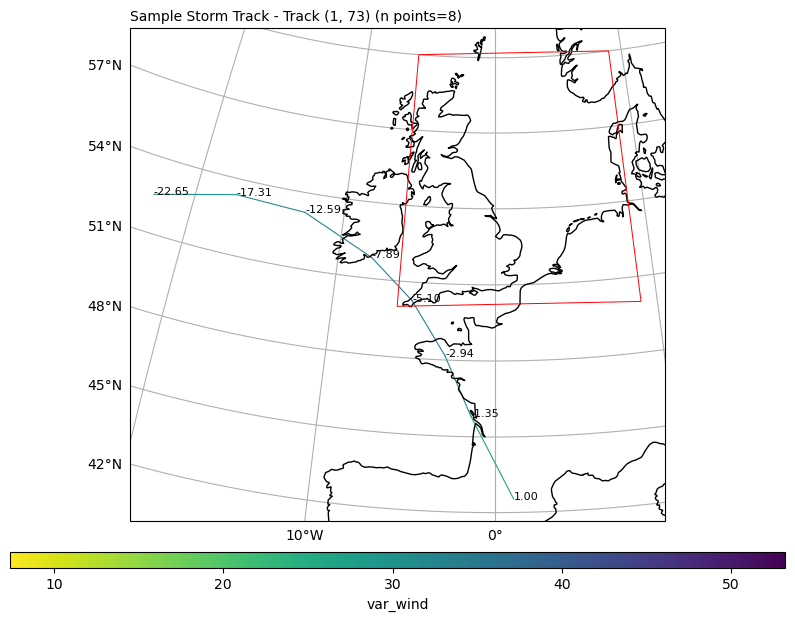

In [207]:
def plot_single_track(data, var, fig_title, uniq_id_sample):
    datacrs = ccrs.PlateCarree()
    mapcrs = ccrs.Orthographic(central_longitude=0, central_latitude=50)  
    
    fig, ax = plt.subplots(figsize=(10., 8.), subplot_kw={'projection': mapcrs})
    ax.add_feature(cfeature.COASTLINE, zorder=17)
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False
    
    cmap = plt.cm.viridis_r
    norm = mcolors.Normalize(vmin=data[var].min(), vmax=data[var].max())

    # Filter the data for the selected sample track
    sample_track = data[data['uniq_id'] == uniq_id_sample]
    sample_track = sample_track.sort_values(by='date')  # Ensure the track is in chronological order

    # Convert the variable to numeric and handle missing values
    sample_track[var] = pd.to_numeric(sample_track[var], errors='coerce')
    sample_track[var] = sample_track[var].fillna(sample_track[var].mean())

    points = sample_track[['lon_vor', 'lat_vor']].values
    color_values = norm(sample_track[var].values)
    colors = cmap(color_values)

    for i in range(len(points)):
        if i < len(points) - 1:
            line = np.array([points[i], points[i + 1]])
            mid_value = norm((sample_track[var].iloc[i] + sample_track[var].iloc[i + 1]) / 2)
            ax.plot(line[:, 0], line[:, 1], color=cmap(mid_value), linewidth=0.8, transform=datacrs)
        
        # Annotate each point with the lon_vor value
        lon_vor_value = points[i][0]
        ax.text(points[i][0], points[i][1], f'{lon_vor_value:.2f}', fontsize=8, transform=datacrs)

    ax.add_patch(mpatches.Rectangle(xy=[-6, 50], width=15, height=10, zorder=18, linewidth=0.7,
                                    facecolor='none', edgecolor='red', transform=datacrs))
    
    n_points = len(sample_track)
    ax.set_title(f"{fig_title} - Track {uniq_id_sample} (n points={n_points})", fontsize=10, loc='left')
    labelin = f'{var}'
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, pad=0.05, aspect=50,
                 orientation='horizontal', label=labelin)
    plt.show()

# Example usage:
# Assuming 'trx_pro_north' is the DataFrame with the filtered data and contains a 'var' column.
# Replace 'sample_var' with the actual variable name you want to plot (e.g., 'var_wind').
sample_uniq_id = trx_pro_north['uniq_id'].iloc[0]  # Choose the first track for demonstration
plot_single_track(trx_pro_north, 'var_wind', "Sample Storm Track", sample_uniq_id)

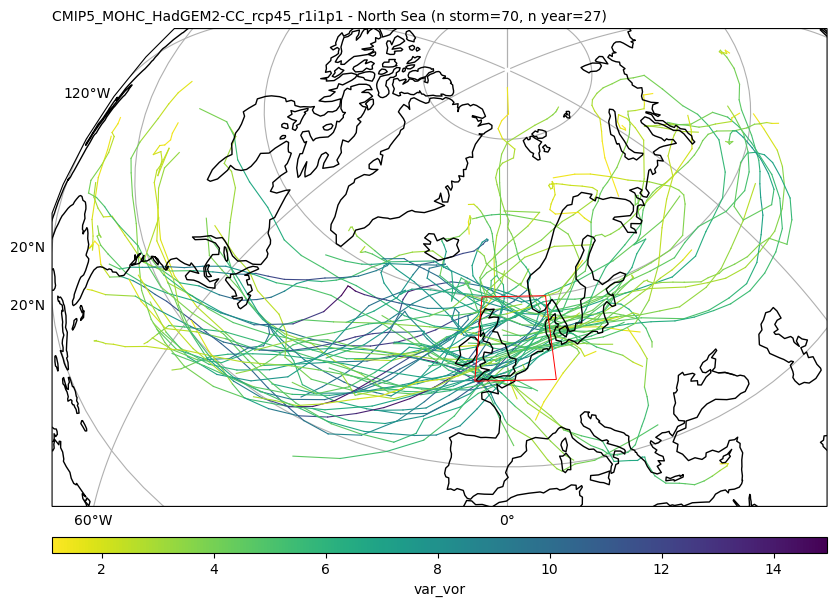

In [209]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1 - North Sea')

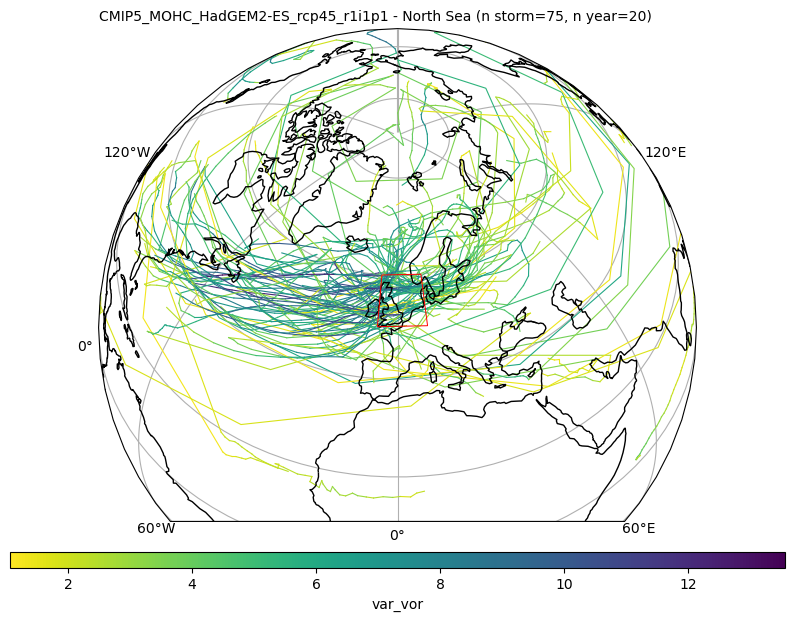

In [151]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-ES_rcp45_r1i1p1 - North Sea')

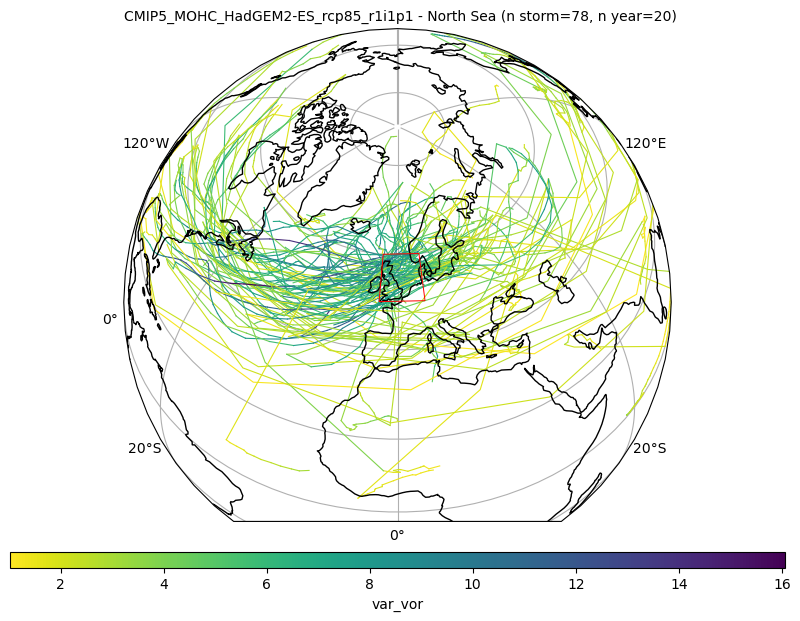

In [143]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1 - North Sea')

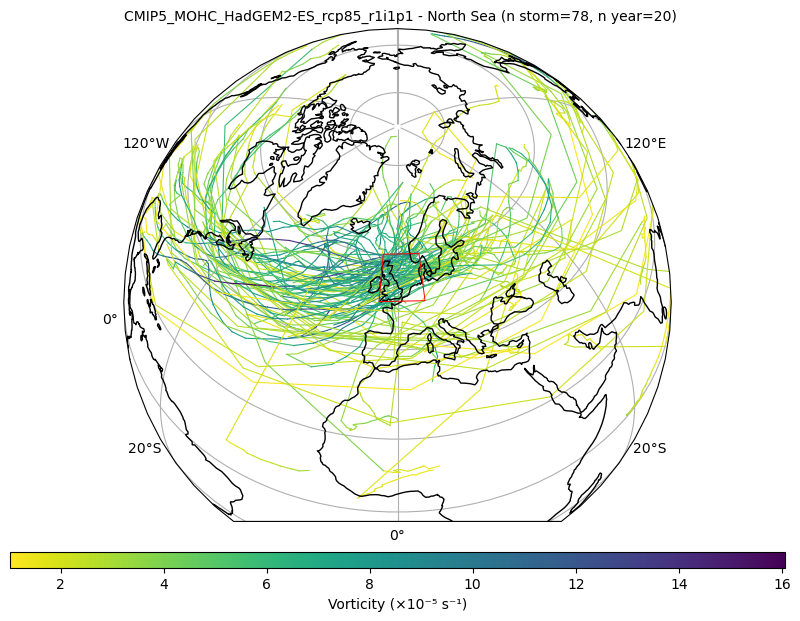

In [102]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1 - North Sea')

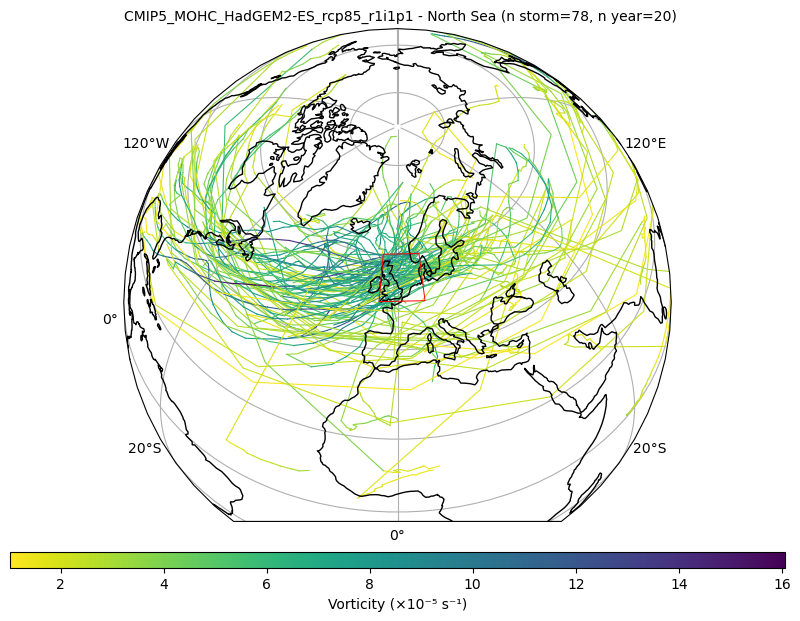

In [65]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-ES_rcp85_r1i1p1 - North Sea')

## Scratch

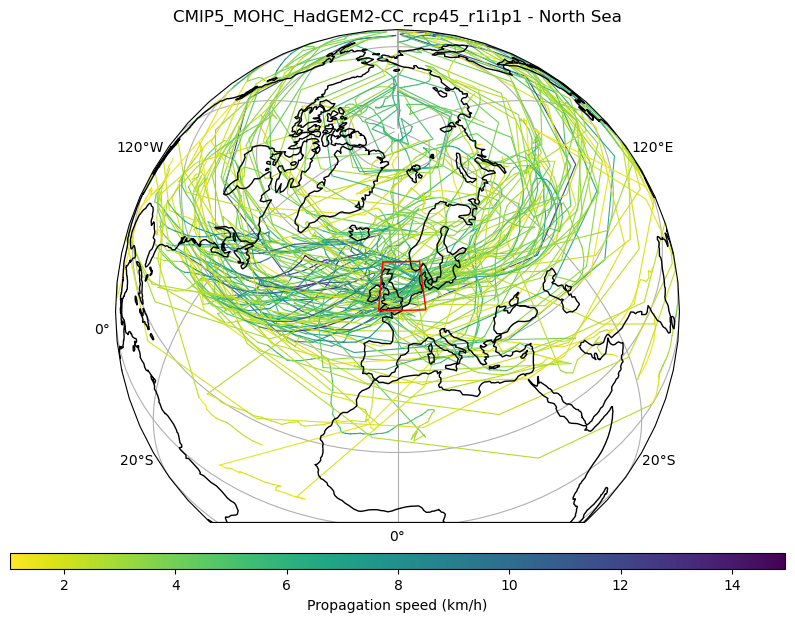

In [162]:
plot_track(trx_pro_north, 'var_vor', 'CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1 - North Sea')

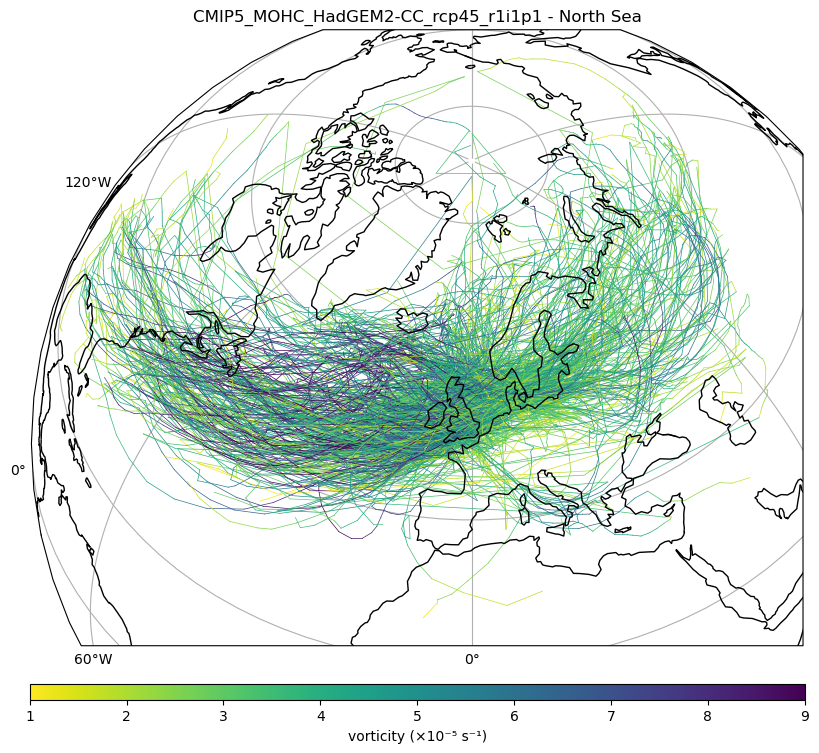

In [50]:
plot_track(trx_pro_north, 'speed', 'CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1 - North Sea')

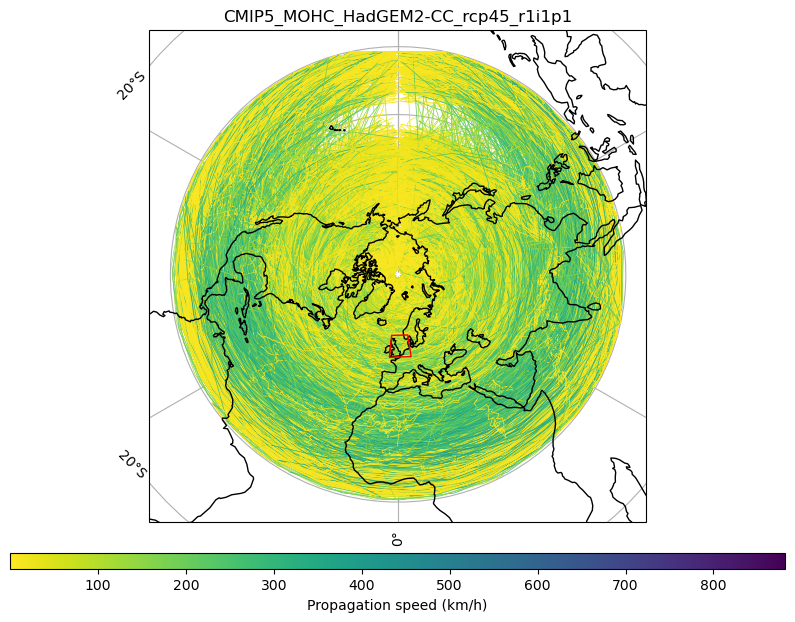

In [22]:
plot_track(trx_pro, 'speed', 'CMIP5_MOHC_HadGEM2-CC_rcp45_r1i1p1')

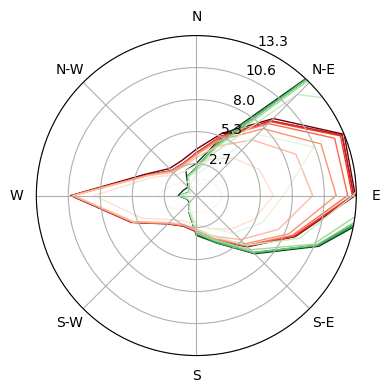

In [20]:
trx_dir_all = trx_pro.dropna(subset=['bearing', 'speed'])
northsea_bound = trx_dir_all[(trx_dir_all['lon_vor'] >= -4) & (trx_dir_all['lon_vor'] <= 10) & 
                      (trx_dir_all['lat_vor'] >= 50) & (trx_dir_all['lat_vor'] <= 60)]
trx_dir_north = northsea_bound.dropna(subset=['bearing', 'speed'])

fig = plt.figure(figsize=(4, 4))  # Adjust figure size for better visibility
ax = WindroseAxes.from_ax(fig=fig)

#ax.contourf(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.Blues, alpha=0.9, normed=True)
ax.contour(trx_dir_all['bearing'].values, trx_dir_all['speed'].values, bins=np.arange(0, 45, 5), cmap=cm.Reds, lw=1, alpha=1, normed=True)

#ax.contourf(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 45, 5), cmap=plt.cm.Reds, alpha=0.4, normed=True)
ax.contour(trx_dir_north['bearing'].values, trx_dir_north['speed'].values, bins=np.arange(0, 45, 5), cmap=cm.Greens, lw=1, alpha=1, normed=True)

#ax.set_legend(title="Storm propagation \nspeed (km/h)", loc="lower left")
plt.show()